# Fit st and fpt with uncertainties in their slopes and breakpoint  
- Use this to find uncertainties in early slopes of FPT and ST fit  
- Then do T test to compare it with early slope of FN  
- also added hom-bonferrini correction

In [2]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress 
from scipy.optimize import curve_fit
from scipy import stats
from scipy import linalg
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap

from scipy import stats
from statsmodels.stats.multitest import multipletests

In [3]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Piecewise linear fit define function 

In [4]:
data_folder = Path('../../data/results/calculate_final_params')
files=glob.glob(f"{data_folder}/final_*.pkl")
print(files)

['..\\..\\data\\results\\calculate_final_params\\final_bla.pkl', '..\\..\\data\\results\\calculate_final_params\\final_enti.pkl', '..\\..\\data\\results\\calculate_final_params\\final_fn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lha.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lsc.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mob.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mop.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mos.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mrn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_orb.pkl', '..\\..\\data\\results\\calculate_final_params\\final_peri.pkl', '..\\..\\data\\results\\calculate_final_params\\final_pir.pkl', '..\\..\\data\\results\\calculate_final_params\\final_re.pkl']


#### Old piecewise linear fit function: It uses 'linear ' method. We got better fit and all errors by 'non linear' method  

In [ ]:
# def fit_piecewiseLinear(data, ax, label):
#     # intervals as this is the time when state changes from another state
    
#     intervals = data.copy()
#     # print(f'original values: {intervals}')
#     intervals = np.sort(intervals)
#     n = len(intervals)

#     # CCDF: P(T > t)
#     ccdf = 1.0 - np.arange(1, n + 1) / n

#     # Remove zero values (log undefined)
#     mask = ccdf > 0
#     intervals = intervals[mask]
#     ccdf = ccdf[mask]

#     # Log of CCDF
#     log_ccdf = np.log(ccdf)

#     x = intervals
#     y = log_ccdf

#     # Fit piecewise linear model with 2 segments
#     my_pwlf = pwlf.PiecewiseLinFit(x, y)
#     res = my_pwlf.fit(2)

#     # Breakpoints returned by pwlf.fit
#     breakpoints = res   # e.g. [min_x, breakpoint, max_x]

#     # First segment is between breakpoints[0] and breakpoints[1]
#     # finding out interval values which contributed to slope 1
#     mask_slope1 = (x >= breakpoints[0]) & (x <= breakpoints[1])
#     entries_slope1 = x[mask_slope1]

#     # print("Entries belonging to slope 1:", entries_slope1.tolist())
#      # Entries corresponding to slope 2 (between res[1] and res[2])
#     mask2 = (x >= res[1]) & (x <= res[2])
#     entries_slope2 = x[mask2]

#     # Predict
#     y_hat = my_pwlf.predict(x)

#     # Plot
#     ax.scatter(x, y, label="Data")
#     ax.plot(x, y_hat, 'r', label="Piecewise fit")
#     ax.set_ylabel("log P(T > t)")
#     ax.set_title(f"Log-CCDF breakpoint ~ {round(res[1])} {label}")
#     ax.legend()

#     # Slopes of the fitted lines
#     slopes = my_pwlf.calc_slopes()
#     se_betas=my_pwlf.standard_errors()
    

#     print("Slopes of fitted lines:", slopes)
#     print("SE for early slopes",se_betas)

#     # Optionally annotate slopes on the plot
#     for i, slope in enumerate(slopes):
#         ax.text(x.mean(), y_hat.mean() - i*0.5, f"Slope {i+1}: {slope:.3f}", color="blue")

#     return {'exp':slopes, 'joint': round(res[1]),'slope_1_entries':entries_slope1.tolist(),'s2':entries_slope2.tolist(),'s1_se':se_betas[1]}


New fit functin which gives all errors

In [5]:

def fit_piecewiseLinear(data, ax, label):
    # 1. Prepare Data (CCDF logic)
    intervals = np.sort(data.copy())
    n = len(intervals)
    ccdf = 1.0 - np.arange(1, n + 1) / n
    mask = ccdf > 0
    x = intervals[mask]
    y = np.log(ccdf[mask])

    # 2. Fit the model
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breakpoints = my_pwlf.fit(2)  # [min_x, joint, max_x]
    joint = breakpoints[1]
    
    # 3. Calculate Joint Error (Standard Error of the breakpoint)
    # The 'non-linear' method treats the breakpoint as a parameter to find its SE
    try:
        se_all = my_pwlf.standard_errors(method='non-linear')
        se_joint = se_all[-1] # The last value is the SE of the interior joint
    except:
        se_joint = np.nan # Fallback if non-linear method isn't supported in your version

    # 4. Manually Construct Regression Matrix A
    # Column 0: Intercept (constant 1s)
    # Column 1: First slope component (x - min_x)
    # Column 2: Second slope component (x - joint, but only where x > joint)
    col0 = np.ones(len(x))
    col1 = x - breakpoints[0]
    col2 = np.maximum(0, x - joint)
    A = np.column_stack([col0, col1, col2])

    # 5. Calculate Slope Errors using Covariance
    # Degree of freedom = n_samples - n_parameters (3 for a 2-segment fit)
    dof = len(x) - 3
    sigma_sq = my_pwlf.ssr / dof
    
    # Covariance Matrix = sigma_sq * (A^T * A)^-1
    # pinv is used for numerical stability
    cov_beta = sigma_sq * linalg.pinv(np.dot(A.T, A))

    # Slope 1 = Beta 1
    se_slope1 = np.sqrt(cov_beta[1, 1])
    
    # Slope 2 = Beta 1 + Beta 2
    # Var(S2) = Var(B1) + Var(B2) + 2*Cov(B1, B2)
    var_slope2 = cov_beta[1, 1] + cov_beta[2, 2] + 2 * cov_beta[1, 2]
    se_slope2 = np.sqrt(max(0, var_slope2))

    # 6. Plotting and Results
    y_hat = my_pwlf.predict(x)
    slopes = my_pwlf.calc_slopes()

    ax.scatter(x, y, alpha=0.3, label=label.split("_")[-1])
    ax.plot(x, y_hat, 'r', linewidth=2, label="Piecewise fit")
    ax.axvline(joint, color='green', linestyle='--', alpha=0.6, 
               label=f"Joint: {joint:.1f} ± {se_joint:.1f}")
    
    # ax.set_title(f"Fit for {label.split('_')[-1]}")
    ax.legend()

    print(f"--- Results for {label} ---")
    print(f"Joint:   {joint:.4f} ± {se_joint:.4f}")
    print(f"Slope 1: {slopes[0]:.4f} ± {se_slope1:.4f}")
    print(f"Slope 2: {slopes[1]:.4f} ± {se_slope2:.4f}")

    return {
        'slopes': slopes.tolist(),
        'slopes_se': [se_slope1, se_slope2],
        'joint': joint,
        'joint_se': se_joint
    }

### part fpt [SUPPLEMENTARY 5.1]

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for part_fpt_bla ---
Joint:   396.7438 ± 4.1880
Slope 1: -0.0028 ± 0.0001
Slope 2: -0.0167 ± 0.0005
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for part_fpt_enti ---
Joint:   525.8788 ± 2.1106
Slope 1: -0.0041 ± 0.0001
Slope 2: -0.0409 ± 0.0013
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for part_fpt_fn ---
Joint:   504.3561 ± 2.0568
Slope 1: -0.0043 ± 0.0001
Slope 2: -0.0335 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for part_fpt_lha ---
Joint:   526.3644 ± 3.0632
Slope 1: -0.0040 ± 0.0001
Slope 2: -0.0483 ± 0.0022
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for part_fpt_lsc ---
Joint:   526.4369 ± 1.3939
Slope 1: -0.0047 ± 0.0001
Slope 2: -0.0521 ± 0.0015
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

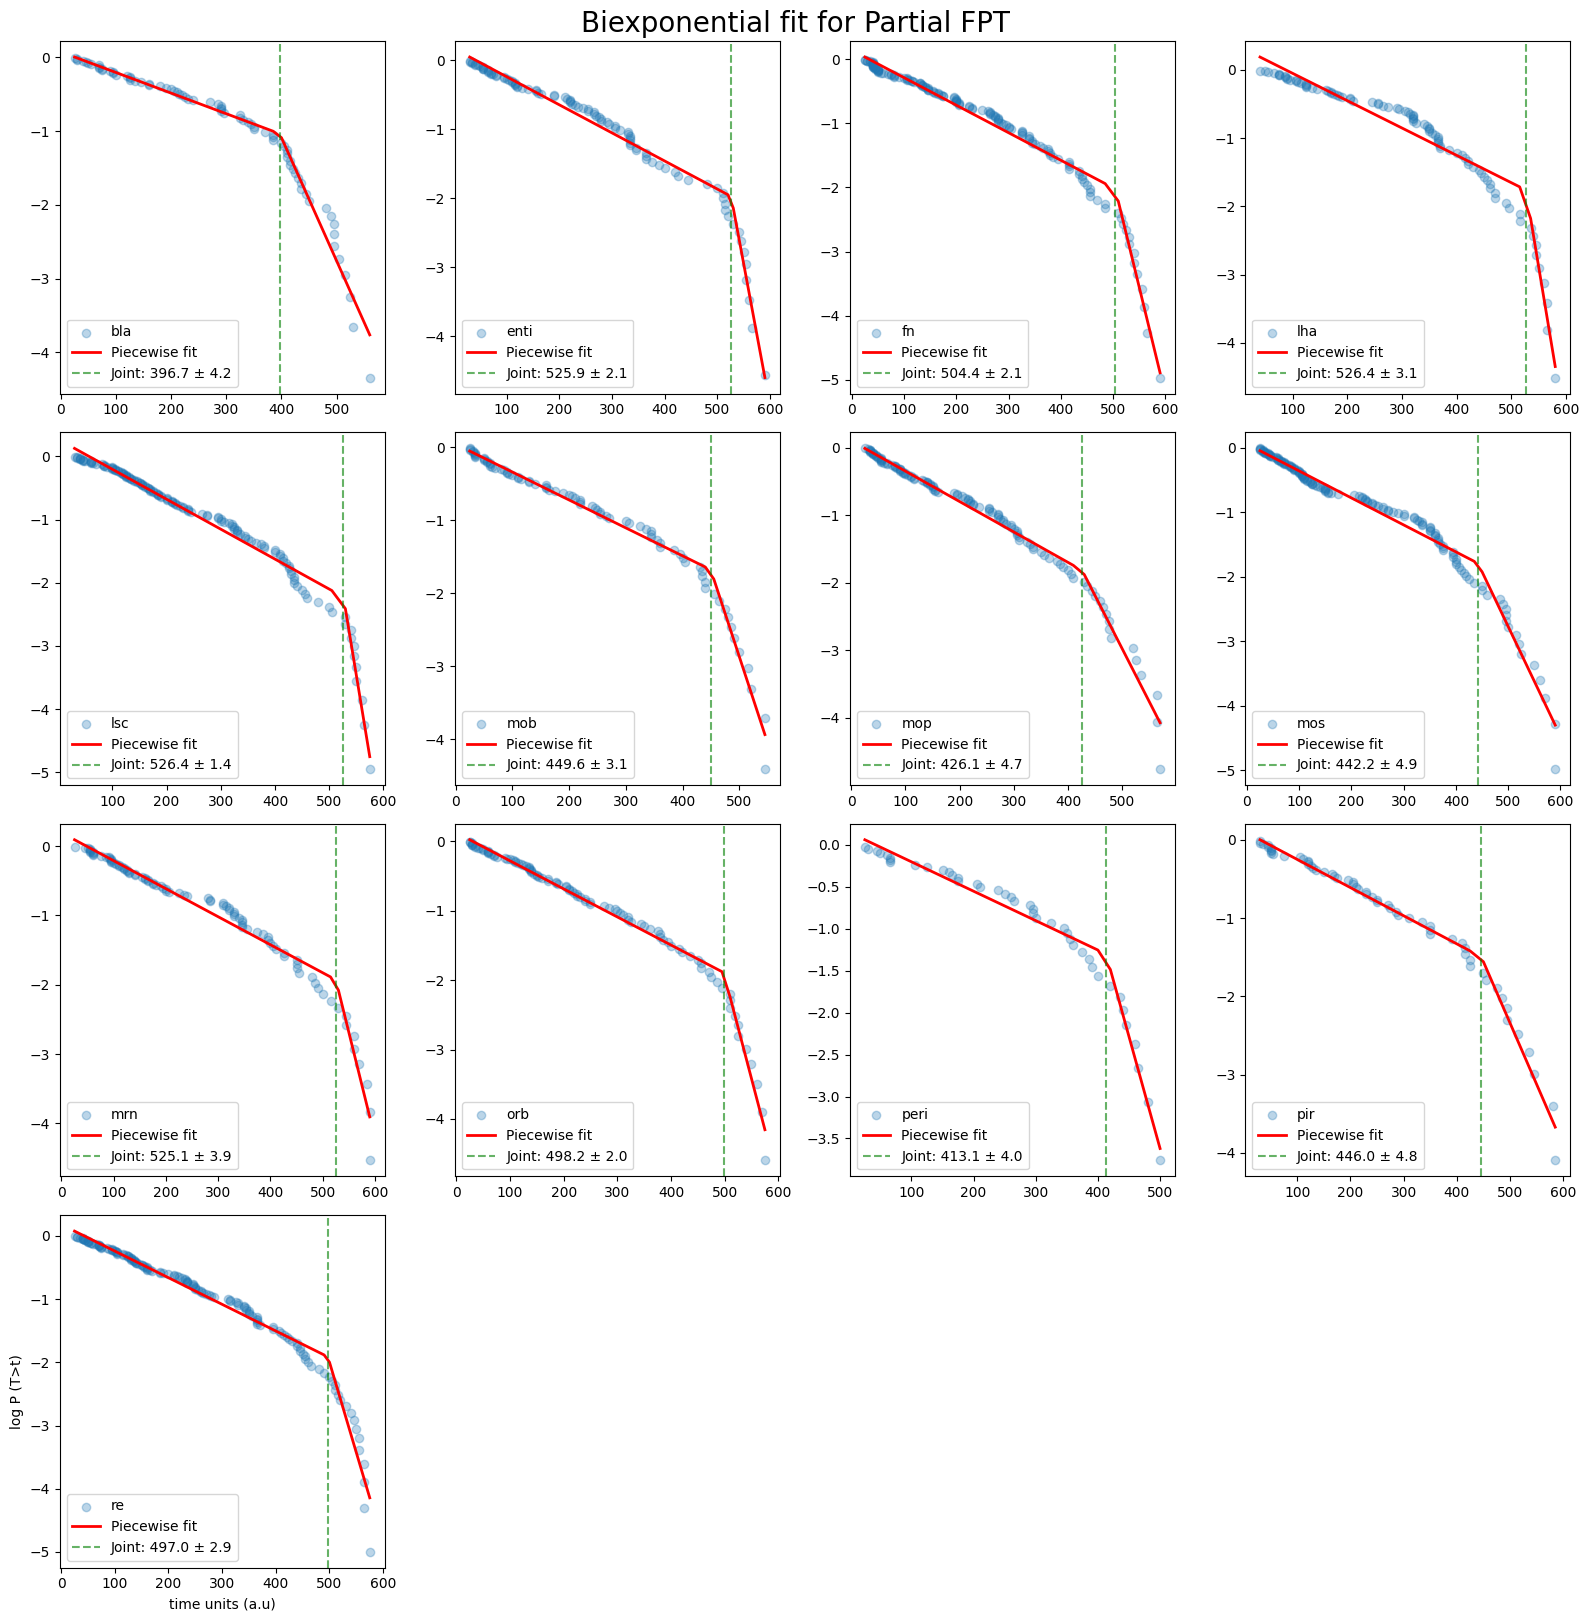

In [6]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_joint_se={}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_fpt = [x for x in params[1]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(part_fpt, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['slopes'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_joint[nw] = p['joint']
    dict_joint_se[nw]=p['joint_se']
    dict_slp1_se[nw]=p['slopes_se'][0]

ax.set_xlabel('time units (a.u)')
ax.set_ylabel('log P (T>t)')
for ax in axes[len(files):]:
    ax.axis("off")

plt.tight_layout()
plt.suptitle('Biexponential fit for Partial FPT',fontsize=20,y=1.01)
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [21]:
dict_slp1_se

{'bla': 0.00013332694466857404,
 'enti': 7.65443947402654e-05,
 'fn': 6.27308454086386e-05,
 'lha': 0.00013386823050275755,
 'lsc': 6.7731851087317e-05,
 'mob': 7.89640798810816e-05,
 'mop': 8.26694657459475e-05,
 'mos': 7.911824111587222e-05,
 'mrn': 9.960592235063545e-05,
 'orb': 5.992481769922017e-05,
 'peri': 0.0001552883051890177,
 'pir': 9.548145544933523e-05,
 're': 8.168362851836458e-05}

Applying T test comparing every with FN

In [7]:
def compare_slopes(m1, se1, m2, se2):
    """
    Returns the t-statistic and p-value for the comparison of two slopes.
    """
    
    # Calculate the t-statistic
    t_stat = (m1 - m2) / np.sqrt(se1**2 + se2**2)
    
    # Calculate p-value (two-tailed)
    # Using normal distribution (Z-test) as a standard approximation for large N
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    return t_stat, p_value

Part FPT corrrected significant networks

In [19]:
# --- 1. Collect statistics and raw p-values across all loops ---
labels = list(dict_exp1.keys())
t_statistics = []
raw_p_values = []

# Reference baseline values ('fn')
ref_m = dict_exp1['fn']
ref_se = dict_slp1_se['fn']

for s, se in zip(dict_exp1.values(), dict_slp1_se.values()):
    t, p = compare_slopes(ref_m, ref_se, s, se)
    t_statistics.append(t)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Correction ---
# alpha=0.05 controls the family-wise error rate 
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Filter and Print Significant Networks ---
nw = []

print(f"{'Network Label':<15} | {'T-stat':<10} | {'Raw p-val':<12} | {'Corr p-val':<12} | {'Significant?'}")
print("-" * 65)

for label, t, raw_p, corr_p, is_significant in zip(labels, t_statistics, raw_p_values, corrected_p_values, reject):
    print(f"{label:<15} | {t:<10.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {is_significant}")
    
    # Use the corrected 'reject' boolean (True if corrected p-value < 0.05)
    if is_significant:
        nw.append(label)

print("\n--- Final List of Significant Networks (dict_exp1) ---")
print(nw)

Network Label   | T-stat     | Raw p-val    | Corr p-val   | Significant?
-----------------------------------------------------------------
bla             | -10.1296   | 0.0000e+00   | 0.0000e+00   | True
enti            | -2.2216    | 2.6309e-02   | 1.8416e-01   | False
fn              | 0.0000     | 1.0000e+00   | 1.0000e+00   | False
lha             | -1.9067    | 5.6558e-02   | 2.2623e-01   | False
lsc             | 4.8513     | 1.2267e-06   | 1.3494e-05   | True
mob             | -4.5439    | 5.5221e-06   | 4.9698e-05   | True
mop             | 2.0995     | 3.5775e-02   | 2.0530e-01   | False
mos             | -0.9960    | 3.1925e-01   | 9.5775e-01   | False
mrn             | -2.1175    | 3.4216e-02   | 2.0530e-01   | False
orb             | -2.8708    | 4.0945e-03   | 3.2756e-02   | True
peri            | -4.6621    | 3.1298e-06   | 3.1298e-05   | True
pir             | -6.0683    | 1.2927e-09   | 1.5512e-08   | True
re              | -0.7187    | 4.7234e-01   | 9.5775e-01   | F

without correction

In [ ]:
# nw=[]
# for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
#     t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
#     # print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")
    

#     # if p<0.05, then nw is significant
#     if p<0.05:
#         nw.append(label)
#     else:
#         pass

In [24]:
nw

['bla', 'enti', 'lsc', 'mob', 'mop', 'mrn', 'orb', 'peri', 'pir']

Compare joints (corrected p val)

In [8]:


# --- 1. Collect statistics and raw p-values across all loops ---
labels = list(dict_joint.keys())
t_statistics = []
raw_p_values = []

# Reference baseline values ('fn')
ref_m = dict_joint['fn']
ref_se = dict_joint_se['fn']

for s, se in zip(dict_joint.values(), dict_joint_se.values()):
    t, p = compare_slopes(ref_m, ref_se, s, se)
    t_statistics.append(t)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Correction ---
# alpha=0.05 controls the family-wise error rate 
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Filter and Print Significant Networks ---
jnw = []

print(f"{'Network Label':<15} | {'T-stat':<10} | {'Raw p-val':<12} | {'Corr p-val':<12} | {'Significant?'}")
print("-" * 65)

for label, t, raw_p, corr_p, is_significant in zip(labels, t_statistics, raw_p_values, corrected_p_values, reject):
    print(f"{label:<15} | {t:<10.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {is_significant}")
    
    # Use the corrected 'reject' boolean (True if corrected p-value < 0.05)
    if is_significant:
        jnw.append(label)

print("\n--- Final List of Significant Networks (dict_joint) ---")
print(jnw)

Network Label   | T-stat     | Raw p-val    | Corr p-val   | Significant?
-----------------------------------------------------------------
bla             | 23.0640    | 0.0000e+00   | 0.0000e+00   | True
enti            | -7.3031    | 2.8111e-13   | 1.6867e-12   | True
fn              | 0.0000     | 1.0000e+00   | 1.0000e+00   | False
lha             | -5.9649    | 2.4476e-09   | 1.2238e-08   | True
lsc             | -8.8869    | 0.0000e+00   | 0.0000e+00   | True
mob             | 14.8148    | 0.0000e+00   | 0.0000e+00   | True
mop             | 15.3622    | 0.0000e+00   | 0.0000e+00   | True
mos             | 11.6659    | 0.0000e+00   | 0.0000e+00   | True
mrn             | -4.7146    | 2.4213e-06   | 9.6854e-06   | True
orb             | 2.1431     | 3.2108e-02   | 9.6324e-02   | False
peri            | 20.3104    | 0.0000e+00   | 0.0000e+00   | True
pir             | 11.2215    | 0.0000e+00   | 0.0000e+00   | True
re              | 2.0685     | 3.8594e-02   | 9.6324e-02   | False

old

In [ ]:
# jnw=[]
# for s,se,label in zip(list(dict_joint.values()),list(dict_joint_se.values()),dict_joint.keys()):
#     t, p = compare_slopes(dict_joint['fn'], dict_joint_se['fn'],s,se)
#     print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

#     # if p<0.05, then nw is significant
#     if p<0.05:
#         jnw.append(label)
#     else:
#         pass

T-statistic: 23.0640, P-value: 0.0000
T-statistic: -7.3031, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -5.9649, P-value: 0.0000
T-statistic: -8.8869, P-value: 0.0000
T-statistic: 14.8148, P-value: 0.0000
T-statistic: 15.3622, P-value: 0.0000
T-statistic: 11.6659, P-value: 0.0000
T-statistic: -4.7146, P-value: 0.0000
T-statistic: 2.1431, P-value: 0.0321
T-statistic: 20.3104, P-value: 0.0000
T-statistic: 11.2215, P-value: 0.0000
T-statistic: 2.0685, P-value: 0.0386


In [10]:
jnw

['bla',
 'enti',
 'lha',
 'lsc',
 'mob',
 'mop',
 'mos',
 'mrn',
 'orb',
 'peri',
 'pir',
 're']

Storing above data for fig5j  

In [12]:
part_fpt={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw,'s_j':jnw}
part_fpt

{'slp1': {'bla': -0.0027967386398349433,
  'enti': -0.0040693887747667735,
  'fn': -0.004289282311310031,
  'lha': -0.004007438622119341,
  'lsc': -0.004737098848395709,
  'mob': -0.003831048702223402,
  'mop': -0.0045070057097631325,
  'mos': -0.004188497857288297,
  'mrn': -0.004040032426754003,
  'orb': -0.004040234081883639,
  'peri': -0.0035085717612979325,
  'pir': -0.003595955284550633,
  're': -0.00421513516943396},
 'bp': {'bla': 396.74729963279833,
  'enti': 525.876868276345,
  'fn': 504.3639650777093,
  'lha': 526.3608116277198,
  'lsc': 526.4390010356492,
  'mob': 449.59716294235665,
  'mop': 426.06257394065125,
  'mos': 442.227708420612,
  'mrn': 525.1155500581197,
  'orb': 498.1538565741633,
  'peri': 413.0730442786993,
  'pir': 445.99081185328316,
  're': 496.99768296617435},
 's_nw': ['bla', 'enti', 'lsc', 'mob', 'mop', 'mrn', 'orb', 'peri', 'pir'],
 's_j': ['bla',
  'enti',
  'lha',
  'lsc',
  'mob',
  'mop',
  'mos',
  'mrn',
  'orb',
  'peri',
  'pir',
  're']}

### FPT full

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for full_fpt_bla ---
Joint:   421.6865 ± 8.6594
Slope 1: -0.0017 ± 0.0007
Slope 2: -0.0156 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for full_fpt_enti ---
Joint:   365.1103 ± 7.7428
Slope 1: -0.0025 ± 0.0002
Slope 2: -0.0119 ± 0.0004
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for full_fpt_fn ---
Joint:   482.9710 ± 4.9632
Slope 1: -0.0035 ± 0.0002
Slope 2: -0.0238 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for full_fpt_lha ---
Joint:   420.3201 ± 9.3859
Slope 1: -0.0020 ± 0.0003
Slope 2: -0.0166 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for full_fpt_lsc ---
Joint:   402.3708 ± 5.6164
Slope 1: -0.0024 ± 0.0002
Slope 2: -0.0166 ± 0.0006
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

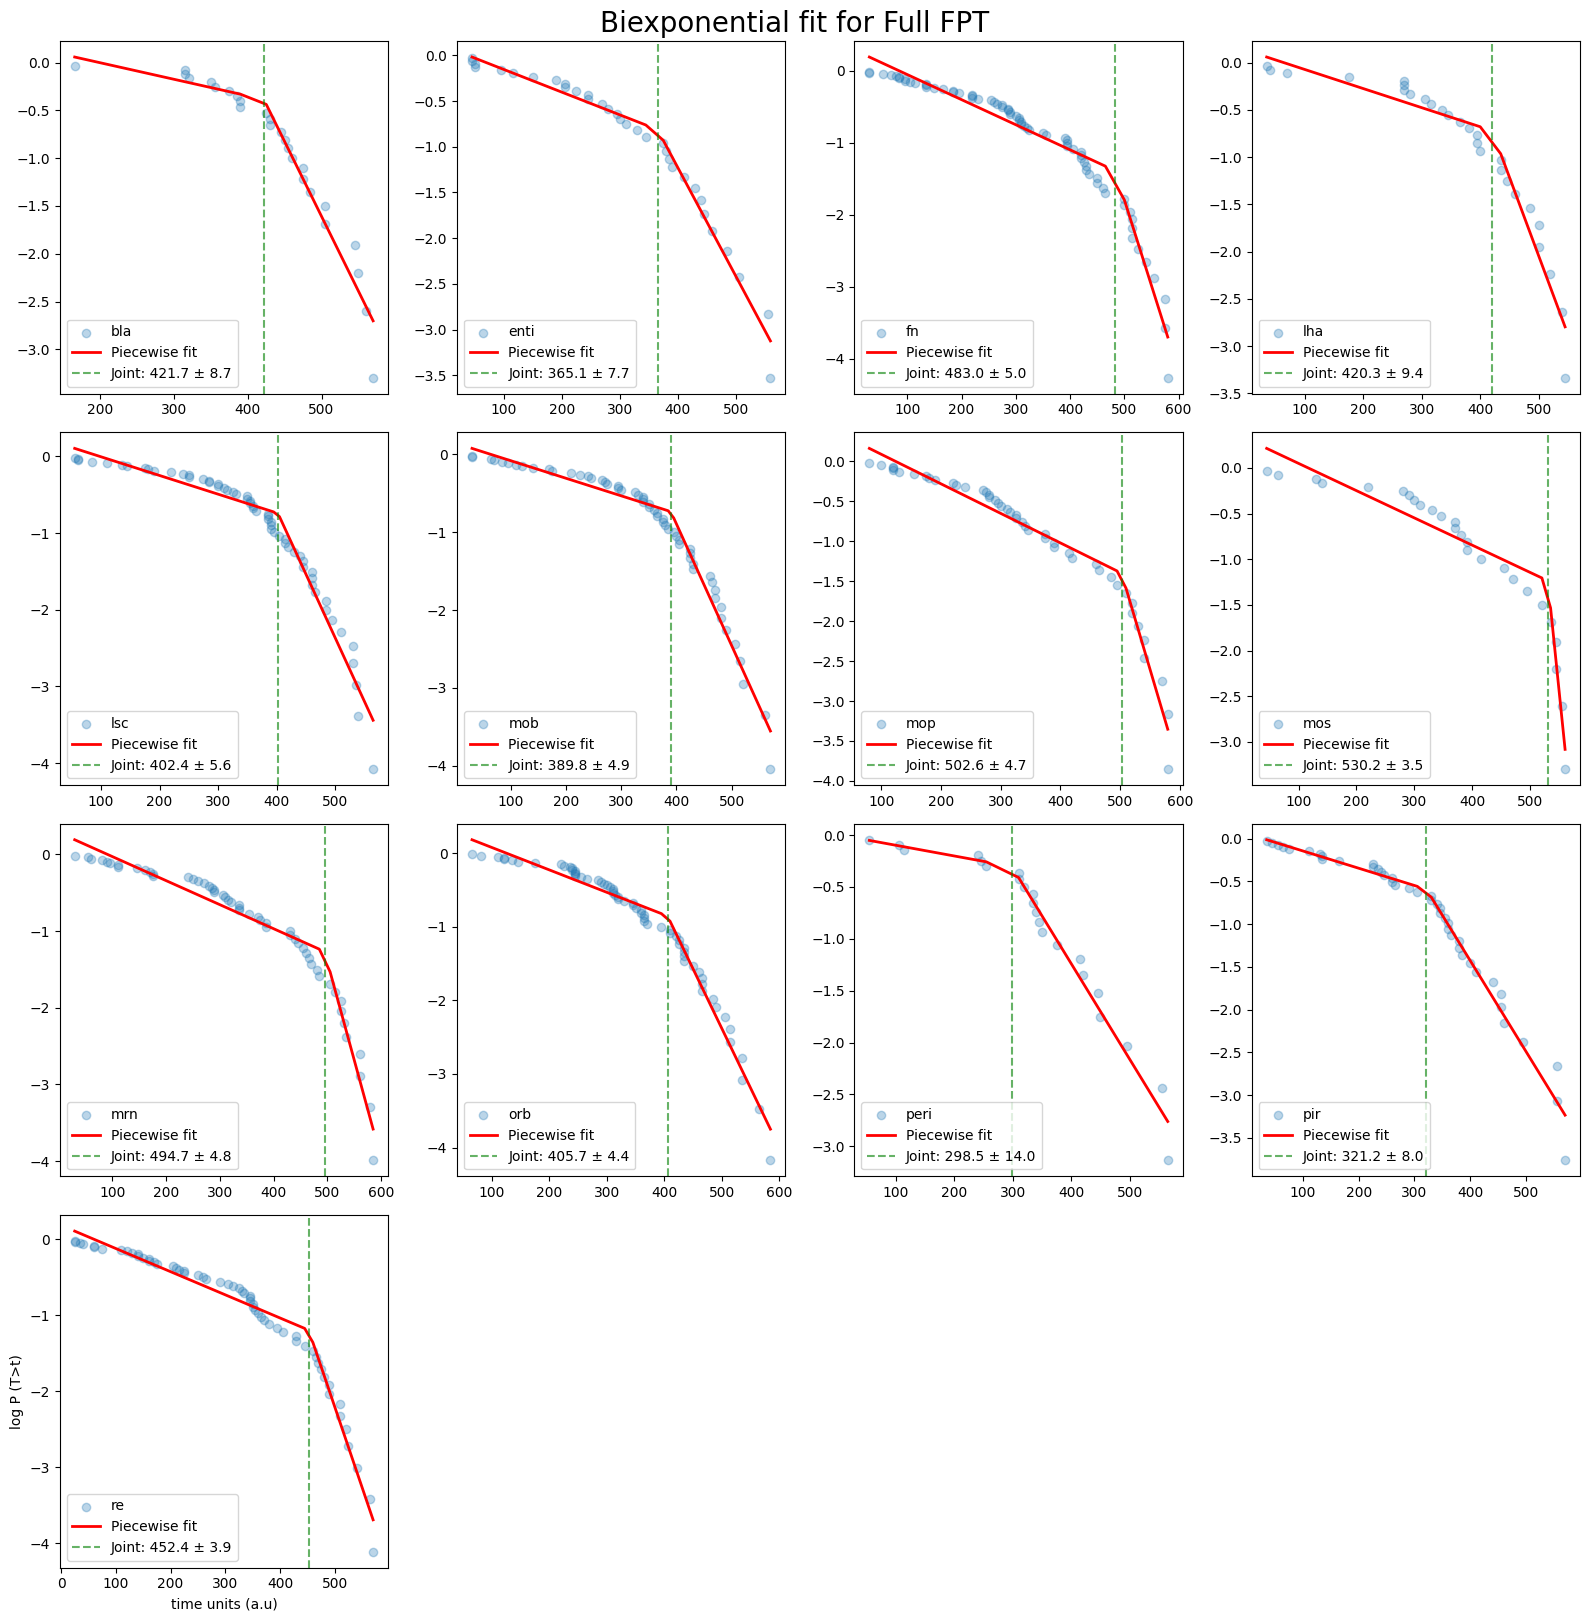

In [22]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_joint_se={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_fpt = [x for x in params[2]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(full_fpt, ax, f"full_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['slopes'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_joint[nw] = p['joint']
    dict_joint_se[nw]=p['joint_se']
    dict_slp1_se[nw]=p['slopes_se'][0]

ax.set_xlabel('time units (a.u)')
ax.set_ylabel('log P (T>t)')
for ax in axes[len(files):]:
    ax.axis("off")

plt.tight_layout()
plt.suptitle('Biexponential fit for Full FPT',fontsize=20,y=1.01)
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


t test

In [23]:
# --- 1. Collect statistics and raw p-values across all loops ---
labels = list(dict_exp1.keys())
t_statistics = []
raw_p_values = []

# Reference baseline values ('fn')
ref_m = dict_exp1['fn']
ref_se = dict_slp1_se['fn']

for s, se in zip(dict_exp1.values(), dict_slp1_se.values()):
    t, p = compare_slopes(ref_m, ref_se, s, se)
    t_statistics.append(t)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Correction ---
# alpha=0.05 controls the family-wise error rate 
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Filter and Print Significant Networks in Table Format ---
nw = []

# Table Header
print(f"{'Network Label':<15} | {'T-statistic':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Significant?'}")
print("-" * 72)

for label, t, raw_p, corr_p, is_significant in zip(labels, t_statistics, raw_p_values, corrected_p_values, reject):
    # This prints every network cleanly aligned in structural columns
    print(f"{label:<15} | {t:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {str(is_significant):<12}")
    
    # Use the corrected 'reject' boolean
    if is_significant:
        nw.append(label)

print("\n--- Final List of Significant Networks (dict_exp1) ---")
print(nw)

Network Label   | T-statistic  | Raw P-value  | Corr P-value | Significant?
------------------------------------------------------------------------
bla             | -2.5529      | 1.0682e-02   | 7.4773e-02   | False       
enti            | -3.9500      | 7.8165e-05   | 7.8165e-04   | True        
fn              | 0.0000       | 1.0000e+00   | 1.0000e+00   | False       
lha             | -3.9059      | 9.3889e-05   | 8.4500e-04   | True        
lsc             | -3.7845      | 1.5404e-04   | 1.2323e-03   | True        
mob             | -5.1537      | 2.5541e-07   | 2.8095e-06   | True        
mop             | 0.8871       | 3.7502e-01   | 7.5004e-01   | False       
mos             | -1.5428      | 1.2289e-01   | 4.6280e-01   | False       
mrn             | -1.5731      | 1.1570e-01   | 4.6280e-01   | False       
orb             | -1.8274      | 6.7645e-02   | 3.3822e-01   | False       
peri            | -5.4163      | 6.0860e-08   | 7.9117e-07   | True        
pir            

In [ ]:
# nw=[]
# for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
#     t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
#     print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

#     # if p<0.05, then nw is significant
#     if p<0.05:
#         nw.append(label)
#     else:
#         pass

T-statistic: -2.5530, P-value: 0.0107
T-statistic: -3.9543, P-value: 0.0001
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -3.9084, P-value: 0.0001
T-statistic: -3.7855, P-value: 0.0002
T-statistic: -5.1546, P-value: 0.0000
T-statistic: 0.8864, P-value: 0.3754
T-statistic: -1.5433, P-value: 0.1228
T-statistic: -1.5737, P-value: 0.1155
T-statistic: -1.8301, P-value: 0.0672
T-statistic: -5.4124, P-value: 0.0000
T-statistic: -5.3095, P-value: 0.0000
T-statistic: -2.1696, P-value: 0.0300


In [13]:
nw

['bla', 'enti', 'lha', 'lsc', 'mob', 'peri', 'pir', 're']

compare joints

In [19]:
# --- 1. Collect statistics and raw p-values across all loops ---
labels = list(dict_joint.keys())
t_statistics = []
raw_p_values = []

# Reference baseline values ('fn')
ref_m = dict_joint['fn']
ref_se = dict_joint_se['fn']

for s, se in zip(dict_joint.values(), dict_joint_se.values()):
    t, p = compare_slopes(ref_m, ref_se, s, se)
    t_statistics.append(t)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Correction ---
# alpha=0.05 controls the family-wise error rate
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Filter and Print Significant Networks in Table Format ---
jnw = []

# Table Header
print(f"{'Network Label':<15} | {'T-statistic':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Significant?'}")
print("-" * 72)

for label, t, raw_p, corr_p, is_significant in zip(labels, t_statistics, raw_p_values, corrected_p_values, reject):
    # This prints every network cleanly aligned in columns
    print(f"{label:<15} | {t:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {str(is_significant):<12}")
    
    # Use the corrected 'reject' boolean
    if is_significant:
        jnw.append(label)

print("\n--- Final List of Significant Networks (dict_joint) ---")
print(jnw)

Network Label   | T-statistic  | Raw P-value  | Corr P-value | Significant?
------------------------------------------------------------------------
bla             | 6.1418       | 8.1592e-10   | 4.8955e-09   | True        
enti            | 12.8219      | 0.0000e+00   | 0.0000e+00   | True        
fn              | 0.0000       | 1.0000e+00   | 1.0000e+00   | False       
lha             | 5.9043       | 3.5406e-09   | 1.7703e-08   | True        
lsc             | 10.7576      | 0.0000e+00   | 0.0000e+00   | True        
mob             | 13.3621      | 0.0000e+00   | 0.0000e+00   | True        
mop             | -2.8687      | 4.1217e-03   | 1.2365e-02   | True        
mos             | -7.8040      | 5.9952e-15   | 4.1966e-14   | True        
mrn             | -1.6900      | 9.1029e-02   | 1.8206e-01   | False       
orb             | 11.6358      | 0.0000e+00   | 0.0000e+00   | True        
peri            | 12.4039      | 0.0000e+00   | 0.0000e+00   | True        
pir            

In [16]:
jnw=[]
for s,se,label in zip(list(dict_joint.values()),list(dict_joint_se.values()),dict_joint.keys()):
    t, p = compare_slopes(dict_joint['fn'], dict_joint_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        jnw.append(label)
    else:
        pass

T-statistic: 6.1418, P-value: 0.0000
T-statistic: 12.8219, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: 5.9043, P-value: 0.0000
T-statistic: 10.7576, P-value: 0.0000
T-statistic: 13.3621, P-value: 0.0000
T-statistic: -2.8687, P-value: 0.0041
T-statistic: -7.8040, P-value: 0.0000
T-statistic: -1.6900, P-value: 0.0910
T-statistic: 11.6358, P-value: 0.0000
T-statistic: 12.4039, P-value: 0.0000
T-statistic: 17.1936, P-value: 0.0000
T-statistic: 4.8426, P-value: 0.0000


In [17]:
jnw

['bla', 'enti', 'lha', 'lsc', 'mob', 'mop', 'mos', 'orb', 'peri', 'pir', 're']

Storing above for fig5j

In [17]:
full_fpt={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw,'s_j':jnw}
full_fpt

{'slp1': {'bla': -0.0017281431470113047,
  'enti': -0.002480980665481094,
  'fn': -0.003485253030402766,
  'lha': -0.00202091068125252,
  'lsc': -0.0024360520271518356,
  'mob': -0.002258856297900321,
  'mop': -0.0036947221939079055,
  'mos': -0.00298577410027598,
  'mrn': -0.003135861469466485,
  'orb': -0.003042955468615255,
  'peri': -0.0010355558820930762,
  'pir': -0.0020175217649611413,
  're': -0.0030488011258202703},
 'bp': {'bla': 421.6843654753038,
  'enti': 365.1331639418863,
  'fn': 482.9726186813084,
  'lha': 420.32111158764405,
  'lsc': 402.3380491961294,
  'mob': 389.78049406563684,
  'mop': 502.6110711334354,
  'mos': 530.1868705323217,
  'mrn': 494.6867644434714,
  'orb': 405.7141639238101,
  'peri': 298.5746609123515,
  'pir': 321.2410918161189,
  're': 452.42547947589026},
 's_nw': ['bla', 'enti', 'lha', 'lsc', 'mob', 'peri', 'pir', 're'],
 's_j': ['bla',
  'enti',
  'lha',
  'lsc',
  'mob',
  'mop',
  'mos',
  'orb',
  'peri',
  'pir',
  're']}

### Part ST

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for bla ---
Joint:   212.0085 ± 3.2484
Slope 1: -0.0186 ± 0.0002
Slope 2: -0.0038 ± 0.0002
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for enti ---
Joint:   103.7242 ± 1.2625
Slope 1: -0.0287 ± 0.0005
Slope 2: -0.0081 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for fn ---
Joint:   157.0576 ± 3.9872
Slope 1: -0.0242 ± 0.0003
Slope 2: -0.0137 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for lha ---
Joint:   125.9114 ± 2.1866
Slope 1: -0.0324 ± 0.0006
Slope 2: -0.0079 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for lsc ---
Joint:   111.4961 ± 1.8733
Slope 1: -0.0228 ± 0.0004
Slope 2: -0.0079 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--- Results for mob ---
Joint:   147.0115 ± 2.6

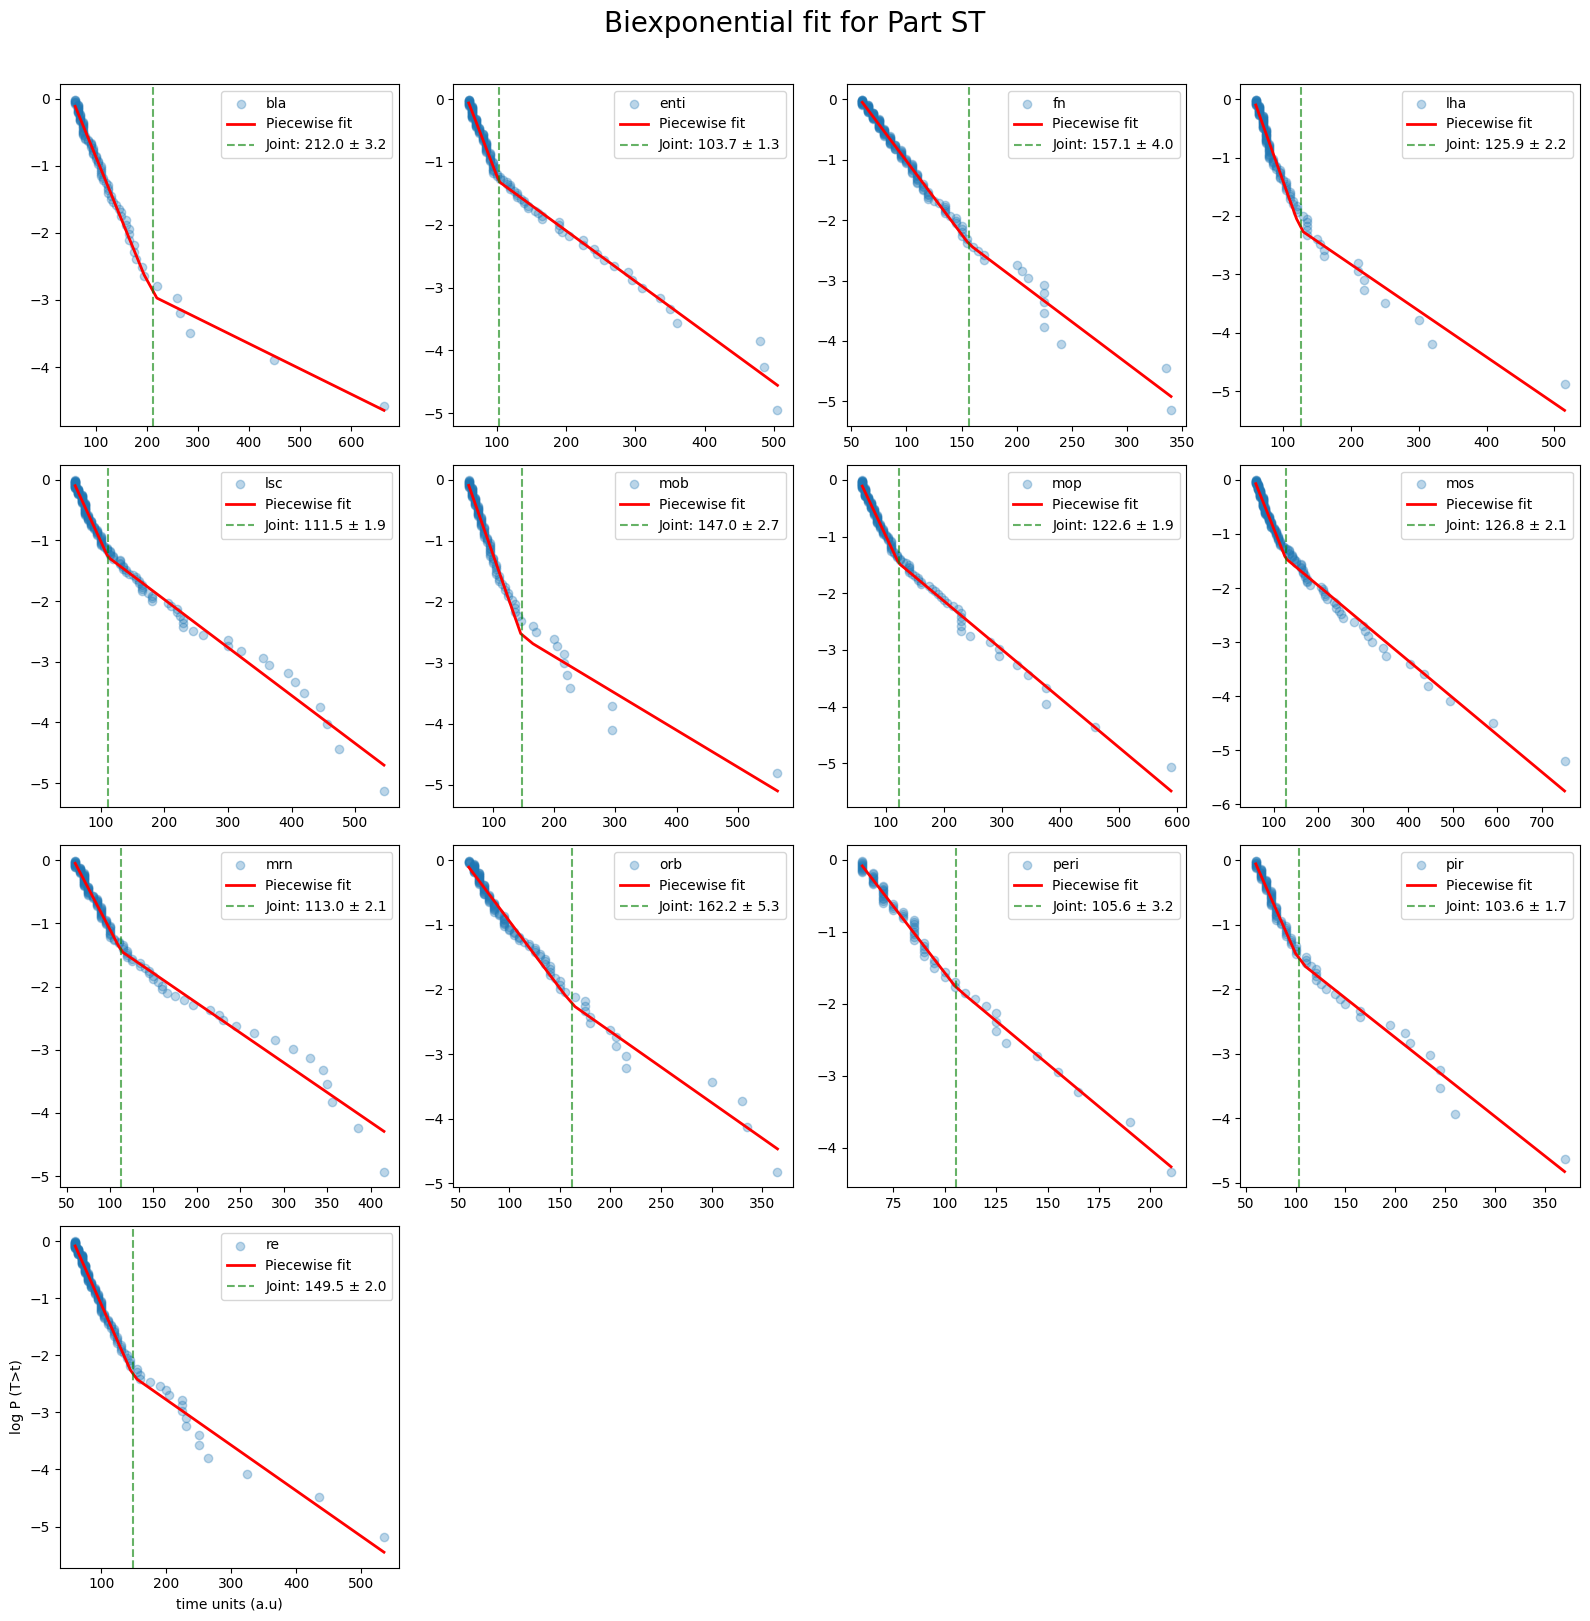

In [24]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_joint_se={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_st = [x for x in params[1]["s_t"] if 25 < x < 800]

    p = fit_piecewiseLinear(part_st, ax, f"{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['slopes'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_joint[nw] = p['joint']
    dict_joint_se[nw]=p['joint_se']
    dict_slp1_se[nw]=p['slopes_se'][0]

ax.set_xlabel('time units (a.u)')
ax.set_ylabel('log P (T>t)')
for ax in axes[len(files):]:
    ax.axis("off")

plt.tight_layout()
plt.suptitle('Biexponential fit for Part ST',fontsize=20,y=1.01)

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


T test on early slope part st

In [27]:
# --- 1. Collect statistics and raw p-values across all loops ---
labels = list(dict_exp1.keys())
t_statistics = []
raw_p_values = []

# Reference baseline values ('fn')
ref_m = dict_exp1['fn']
ref_se = dict_slp1_se['fn']

for s, se in zip(dict_exp1.values(), dict_slp1_se.values()):
    t, p = compare_slopes(ref_m, ref_se, s, se)
    t_statistics.append(t)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Correction ---
# alpha=0.05 controls the family-wise error rate 
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Filter and Print Significant Networks in Table Format ---
nw = []

# Clean Table Header
print(f"{'Network Label':<15} | {'T-statistic':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Significant?'}")
print("-" * 72)

for label, t, raw_p, corr_p, is_significant in zip(labels, t_statistics, raw_p_values, corrected_p_values, reject):
    # Prints everything beautifully aligned in fixed-width text columns
    print(f"{label:<15} | {t:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {str(is_significant):<12}")
    
    # Use the corrected 'reject' boolean
    if is_significant:
        nw.append(label)

print("\n--- Final List of Significant Networks (dict_exp1) ---")
print(nw)

Network Label   | T-statistic  | Raw P-value  | Corr P-value | Significant?
------------------------------------------------------------------------
bla             | -18.0115     | 0.0000e+00   | 0.0000e+00   | True        
enti            | 8.5263       | 0.0000e+00   | 0.0000e+00   | True        
fn              | 0.0000       | 1.0000e+00   | 1.0000e+00   | False       
lha             | 13.4915      | 0.0000e+00   | 0.0000e+00   | True        
lsc             | -2.9742      | 2.9374e-03   | 5.8749e-03   | True        
mob             | 8.6156       | 0.0000e+00   | 0.0000e+00   | True        
mop             | -6.5301      | 6.5729e-11   | 3.2864e-10   | True        
mos             | -8.8838      | 0.0000e+00   | 0.0000e+00   | True        
mrn             | 3.5553       | 3.7748e-04   | 1.1324e-03   | True        
orb             | -8.1659      | 2.2204e-16   | 1.3323e-15   | True        
peri            | 19.1715      | 0.0000e+00   | 0.0000e+00   | True        
pir            

In [25]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -18.0115, P-value: 0.0000
T-statistic: 8.5263, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: 13.4915, P-value: 0.0000
T-statistic: -2.9742, P-value: 0.0029
T-statistic: 8.6156, P-value: 0.0000
T-statistic: -6.5301, P-value: 0.0000
T-statistic: -8.8838, P-value: 0.0000
T-statistic: 3.5553, P-value: 0.0004
T-statistic: -8.1659, P-value: 0.0000
T-statistic: 19.1715, P-value: 0.0000
T-statistic: 14.9957, P-value: 0.0000
T-statistic: 3.7223, P-value: 0.0002


In [26]:
nw

['bla',
 'enti',
 'lha',
 'lsc',
 'mob',
 'mop',
 'mos',
 'mrn',
 'orb',
 'peri',
 'pir',
 're']

Compare joint

In [32]:
# --- 1. Collect statistics and raw p-values across all loops ---
labels = list(dict_joint.keys())
t_statistics = []
raw_p_values = []

# Reference baseline values ('fn')
ref_m = dict_joint['fn']
ref_se = dict_joint_se['fn']

for s, se in zip(dict_joint.values(), dict_joint_se.values()):
    t, p = compare_slopes(ref_m, ref_se, s, se)
    t_statistics.append(t)
    raw_p_values.append(p)

# --- 2. Apply Holm-Bonferroni Correction ---
# alpha=0.05 controls the family-wise error rate
reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# --- 3. Filter and Print Significant Networks in Table Format ---
jnw = []

# Clean Table Header
print(f"{'Network Label':<15} | {'T-statistic':<12} | {'Raw P-value':<12} | {'Corr P-value':<12} | {'Significant?'}")
print("-" * 72)

for label, t, raw_p, corr_p, is_significant in zip(labels, t_statistics, raw_p_values, corrected_p_values, reject):
    # Prints everything beautifully aligned in fixed-width text columns
    print(f"{label:<15} | {t:<12.4f} | {raw_p:<12.4e} | {corr_p:<12.4e} | {str(is_significant):<12}")
    
    # Use the corrected 'reject' boolean
    if is_significant:
        jnw.append(label)

print("\n--- Final List of Significant Networks (dict_joint) ---")
print(jnw)

Network Label   | T-statistic  | Raw P-value  | Corr P-value | Significant?
------------------------------------------------------------------------
bla             | -10.6847     | 0.0000e+00   | 0.0000e+00   | True        
enti            | 12.7521      | 0.0000e+00   | 0.0000e+00   | True        
fn              | 0.0000       | 1.0000e+00   | 1.0000e+00   | False       
lha             | 6.8491       | 7.4298e-12   | 4.4579e-11   | True        
lsc             | 10.3423      | 0.0000e+00   | 0.0000e+00   | True        
mob             | 2.0938       | 3.6273e-02   | 1.4509e-01   | False       
mop             | 7.7971       | 6.4393e-15   | 4.5075e-14   | True        
mos             | 6.7073       | 1.9829e-11   | 9.9147e-11   | True        
mrn             | 9.7648       | 0.0000e+00   | 0.0000e+00   | True        
orb             | -0.7759      | 4.3781e-01   | 8.7561e-01   | False       
peri            | 10.0762      | 0.0000e+00   | 0.0000e+00   | True        
pir            

In [ ]:
# jnw=[]
# for s,se,label in zip(list(dict_joint.values()),list(dict_joint_se.values()),dict_joint.keys()):
#     t, p = compare_slopes(dict_joint['fn'], dict_joint_se['fn'],s,se)
#     print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

#     # if p<0.05, then nw is significant
#     if p<0.05:
#         jnw.append(label)
#     else:
#         pass

T-statistic: -10.6847, P-value: 0.0000
T-statistic: 12.7521, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: 6.8491, P-value: 0.0000
T-statistic: 10.3423, P-value: 0.0000
T-statistic: 2.0938, P-value: 0.0363
T-statistic: 7.7971, P-value: 0.0000
T-statistic: 6.7073, P-value: 0.0000
T-statistic: 9.7648, P-value: 0.0000
T-statistic: -0.7759, P-value: 0.4378
T-statistic: 10.0762, P-value: 0.0000
T-statistic: 12.3320, P-value: 0.0000
T-statistic: 1.7017, P-value: 0.0888


In [30]:
jnw

['bla', 'enti', 'lha', 'lsc', 'mob', 'mop', 'mos', 'mrn', 'peri', 'pir']

In [21]:
part_st={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw,'s_j':jnw}


Data for figure 5j

In [ ]:
reader.data_dump_pkl('results/figures/fig5j_data.pkl',{'fpt_part':part_fpt,
                                                       'fpt_full':full_fpt,
                                                       'st_part':part_st})

In [23]:
full_fpt

{'slp1': {'bla': -0.0017281431470113047,
  'enti': -0.002480980665481094,
  'fn': -0.003485253030402766,
  'lha': -0.00202091068125252,
  'lsc': -0.0024360520271518356,
  'mob': -0.002258856297900321,
  'mop': -0.0036947221939079055,
  'mos': -0.00298577410027598,
  'mrn': -0.003135861469466485,
  'orb': -0.003042955468615255,
  'peri': -0.0010355558820930762,
  'pir': -0.0020175217649611413,
  're': -0.0030488011258202703},
 'bp': {'bla': 421.6843654753038,
  'enti': 365.1331639418863,
  'fn': 482.9726186813084,
  'lha': 420.32111158764405,
  'lsc': 402.3380491961294,
  'mob': 389.78049406563684,
  'mop': 502.6110711334354,
  'mos': 530.1868705323217,
  'mrn': 494.6867644434714,
  'orb': 405.7141639238101,
  'peri': 298.5746609123515,
  'pir': 321.2410918161189,
  're': 452.42547947589026},
 's_nw': ['bla', 'enti', 'lha', 'lsc', 'mob', 'peri', 'pir', 're'],
 's_j': ['bla',
  'enti',
  'lha',
  'lsc',
  'mob',
  'mop',
  'mos',
  'orb',
  'peri',
  'pir',
  're']}

For figure 6

### New Piecewise linear fit function which uses 'non linear' algorithm and gives error for all

In [4]:

def fit_piecewiseLinear(data, ax, label):
    # 1. Prepare Data (CCDF logic)
    intervals = np.sort(data.copy())
    n = len(intervals)
    ccdf = 1.0 - np.arange(1, n + 1) / n
    mask = ccdf > 0
    x = intervals[mask]
    y = np.log(ccdf[mask])

    # 2. Fit the model
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breakpoints = my_pwlf.fit(2)  # [min_x, joint, max_x]
    joint = breakpoints[1]
    
    # 3. Calculate Joint Error (Standard Error of the breakpoint)
    # The 'non-linear' method treats the breakpoint as a parameter to find its SE
    try:
        se_all = my_pwlf.standard_errors(method='non-linear')
        se_joint = se_all[-1] # The last value is the SE of the interior joint
    except:
        se_joint = np.nan # Fallback if non-linear method isn't supported in your version

    # 4. Manually Construct Regression Matrix A
    # Column 0: Intercept (constant 1s)
    # Column 1: First slope component (x - min_x)
    # Column 2: Second slope component (x - joint, but only where x > joint)
    col0 = np.ones(len(x))
    col1 = x - breakpoints[0]
    col2 = np.maximum(0, x - joint)
    A = np.column_stack([col0, col1, col2])

    # 5. Calculate Slope Errors using Covariance
    # Degree of freedom = n_samples - n_parameters (3 for a 2-segment fit)
    dof = len(x) - 3
    sigma_sq = my_pwlf.ssr / dof
    
    # Covariance Matrix = sigma_sq * (A^T * A)^-1
    # pinv is used for numerical stability
    cov_beta = sigma_sq * linalg.pinv(np.dot(A.T, A))

    # Slope 1 = Beta 1
    se_slope1 = np.sqrt(cov_beta[1, 1])
    
    # Slope 2 = Beta 1 + Beta 2
    # Var(S2) = Var(B1) + Var(B2) + 2*Cov(B1, B2)
    var_slope2 = cov_beta[1, 1] + cov_beta[2, 2] + 2 * cov_beta[1, 2]
    se_slope2 = np.sqrt(max(0, var_slope2))

    # 6. Plotting and Results
    y_hat = my_pwlf.predict(x)
    slopes = my_pwlf.calc_slopes()

    ax.scatter(x, y, alpha=0.3, label="Data")
    ax.plot(x, y_hat, 'r', linewidth=2, label="Piecewise fit")
    ax.axvline(joint, color='green', linestyle='--', alpha=0.6, 
               label=f"Joint: {joint:.1f} ± {se_joint:.1f}")
    
    ax.set_title(f"Fit for {label}")
    ax.legend()

    print(f"--- Results for {label} ---")
    print(f"Joint:   {joint:.4f} ± {se_joint:.4f}")
    print(f"Slope 1: {slopes[0]:.4f} ± {se_slope1:.4f}")
    print(f"Slope 2: {slopes[1]:.4f} ± {se_slope2:.4f}")

    return {
        'slopes': slopes.tolist(),
        'slopes_se': [se_slope1, se_slope2],
        'joint': joint,
        'joint_se': se_joint
    }

1.part fpt

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for part_fpt_bla ---
Joint:   396.7598 ± 4.1874
Slope 1: -0.0028 ± 0.0001
Slope 2: -0.0167 ± 0.0005
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for part_fpt_enti ---
Joint:   525.8769 ± 2.1108
Slope 1: -0.0041 ± 0.0001
Slope 2: -0.0409 ± 0.0013
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for part_fpt_fn ---
Joint:   504.3578 ± 2.0567
Slope 1: -0.0043 ± 0.0001
Slope 2: -0.0335 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for part_fpt_lha ---
Joint:   526.3554 ± 3.0646
Slope 1: -0.0040 ± 0.0001
Slope 2: -0.0482 ± 0.0022
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for part_fpt_lsc ---
Joint:   526.4402 ± 1.3937
Slope 1: -0.0047 ± 0.0001
Slope 2: -0.0521 ± 0.0015
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

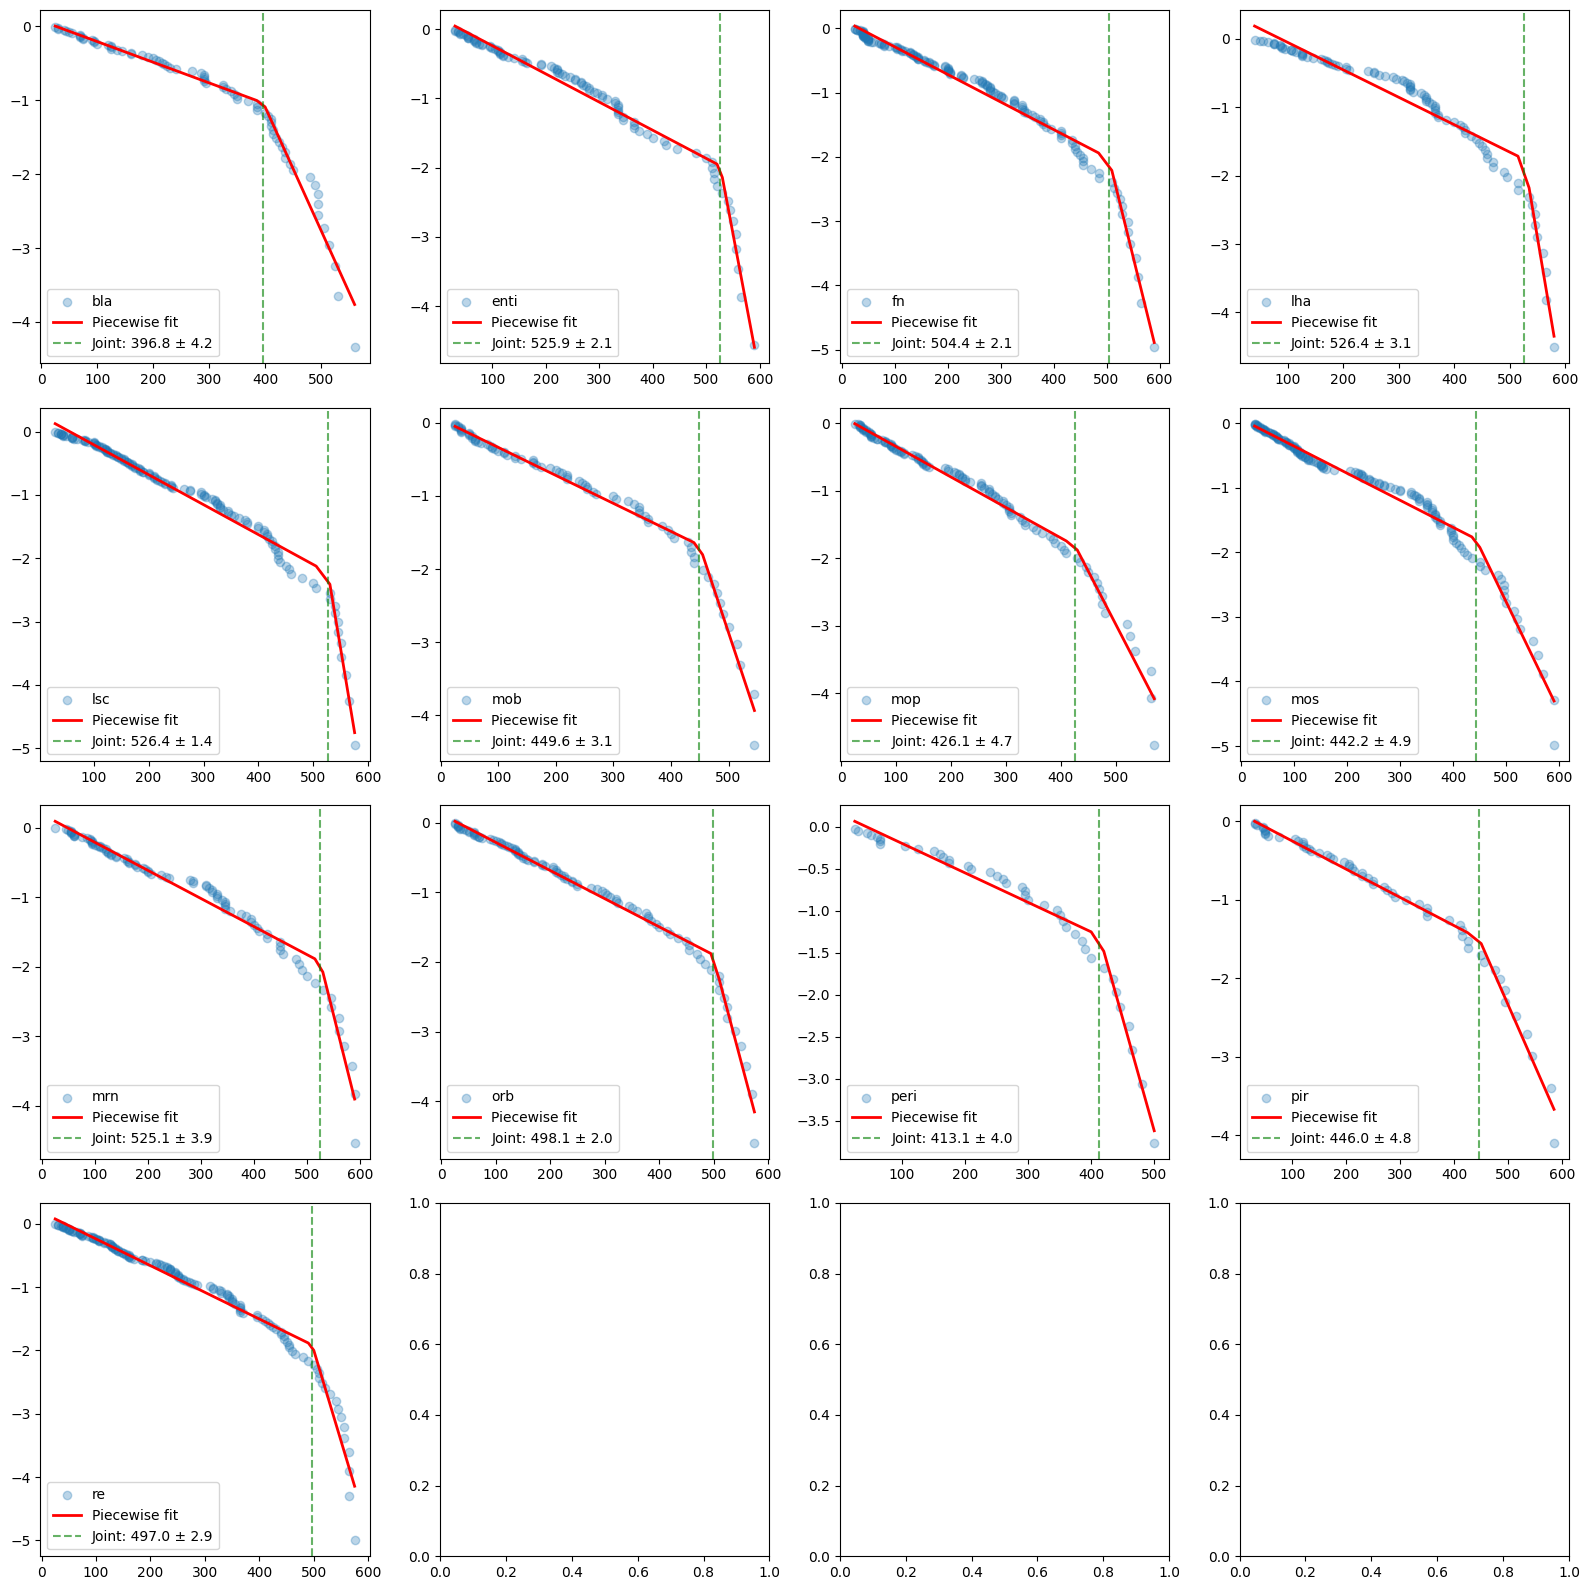

In [33]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp1_se={}
dict_exp2 = {}
dict_exp2_se={}
dict_joint = {}
dict_joint_se={}




for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_fpt = [x for x in params[1]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(part_fpt, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']
    
   
    

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [34]:


# assuming you already have dict_exp1, dict_exp1_se, dict_exp2, dict_exp2_se, dict_joint, dict_joint_se

df_pfpt = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_pfpt)


          exp1   exp1_se      exp2   exp2_se       joint  joint_se
bla  -0.002797  0.000133 -0.016718  0.000455  396.759775  4.187419
enti -0.004069  0.000077 -0.040911  0.001275  525.876862  2.110827
fn   -0.004289  0.000063 -0.033457  0.000797  504.357812  2.056657
lha  -0.004007  0.000134 -0.048248  0.002172  526.355441  3.064626
lsc  -0.004737  0.000068 -0.052076  0.001459  526.440201  1.393681
mob  -0.003831  0.000079 -0.023690  0.000613  449.594005  3.071395
mop  -0.004507  0.000083 -0.015717  0.000397  426.108637  4.660120
mos  -0.004189  0.000079 -0.016997  0.000423  442.241876  4.911062
mrn  -0.004040  0.000100 -0.030481  0.001212  525.108291  3.892031
orb  -0.004040  0.000060 -0.029435  0.000665  498.145103  2.036199
peri -0.003509  0.000155 -0.026700  0.001042  413.079600  3.994742
pir  -0.003596  0.000095 -0.015653  0.000443  445.998486  4.776708
re   -0.004215  0.000082 -0.028616  0.000832  497.006156  2.893623


2. Full FPT

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for full_fpt_bla ---
Joint:   421.6835 ± 8.6593
Slope 1: -0.0017 ± 0.0007
Slope 2: -0.0156 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for full_fpt_enti ---
Joint:   365.1257 ± 7.7423
Slope 1: -0.0025 ± 0.0002
Slope 2: -0.0119 ± 0.0004
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for full_fpt_fn ---
Joint:   482.9623 ± 4.9642
Slope 1: -0.0035 ± 0.0002
Slope 2: -0.0238 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for full_fpt_lha ---
Joint:   420.2883 ± 9.3901
Slope 1: -0.0020 ± 0.0003
Slope 2: -0.0166 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for full_fpt_lsc ---
Joint:   402.3630 ± 5.6169
Slope 1: -0.0024 ± 0.0002
Slope 2: -0.0166 ± 0.0006
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

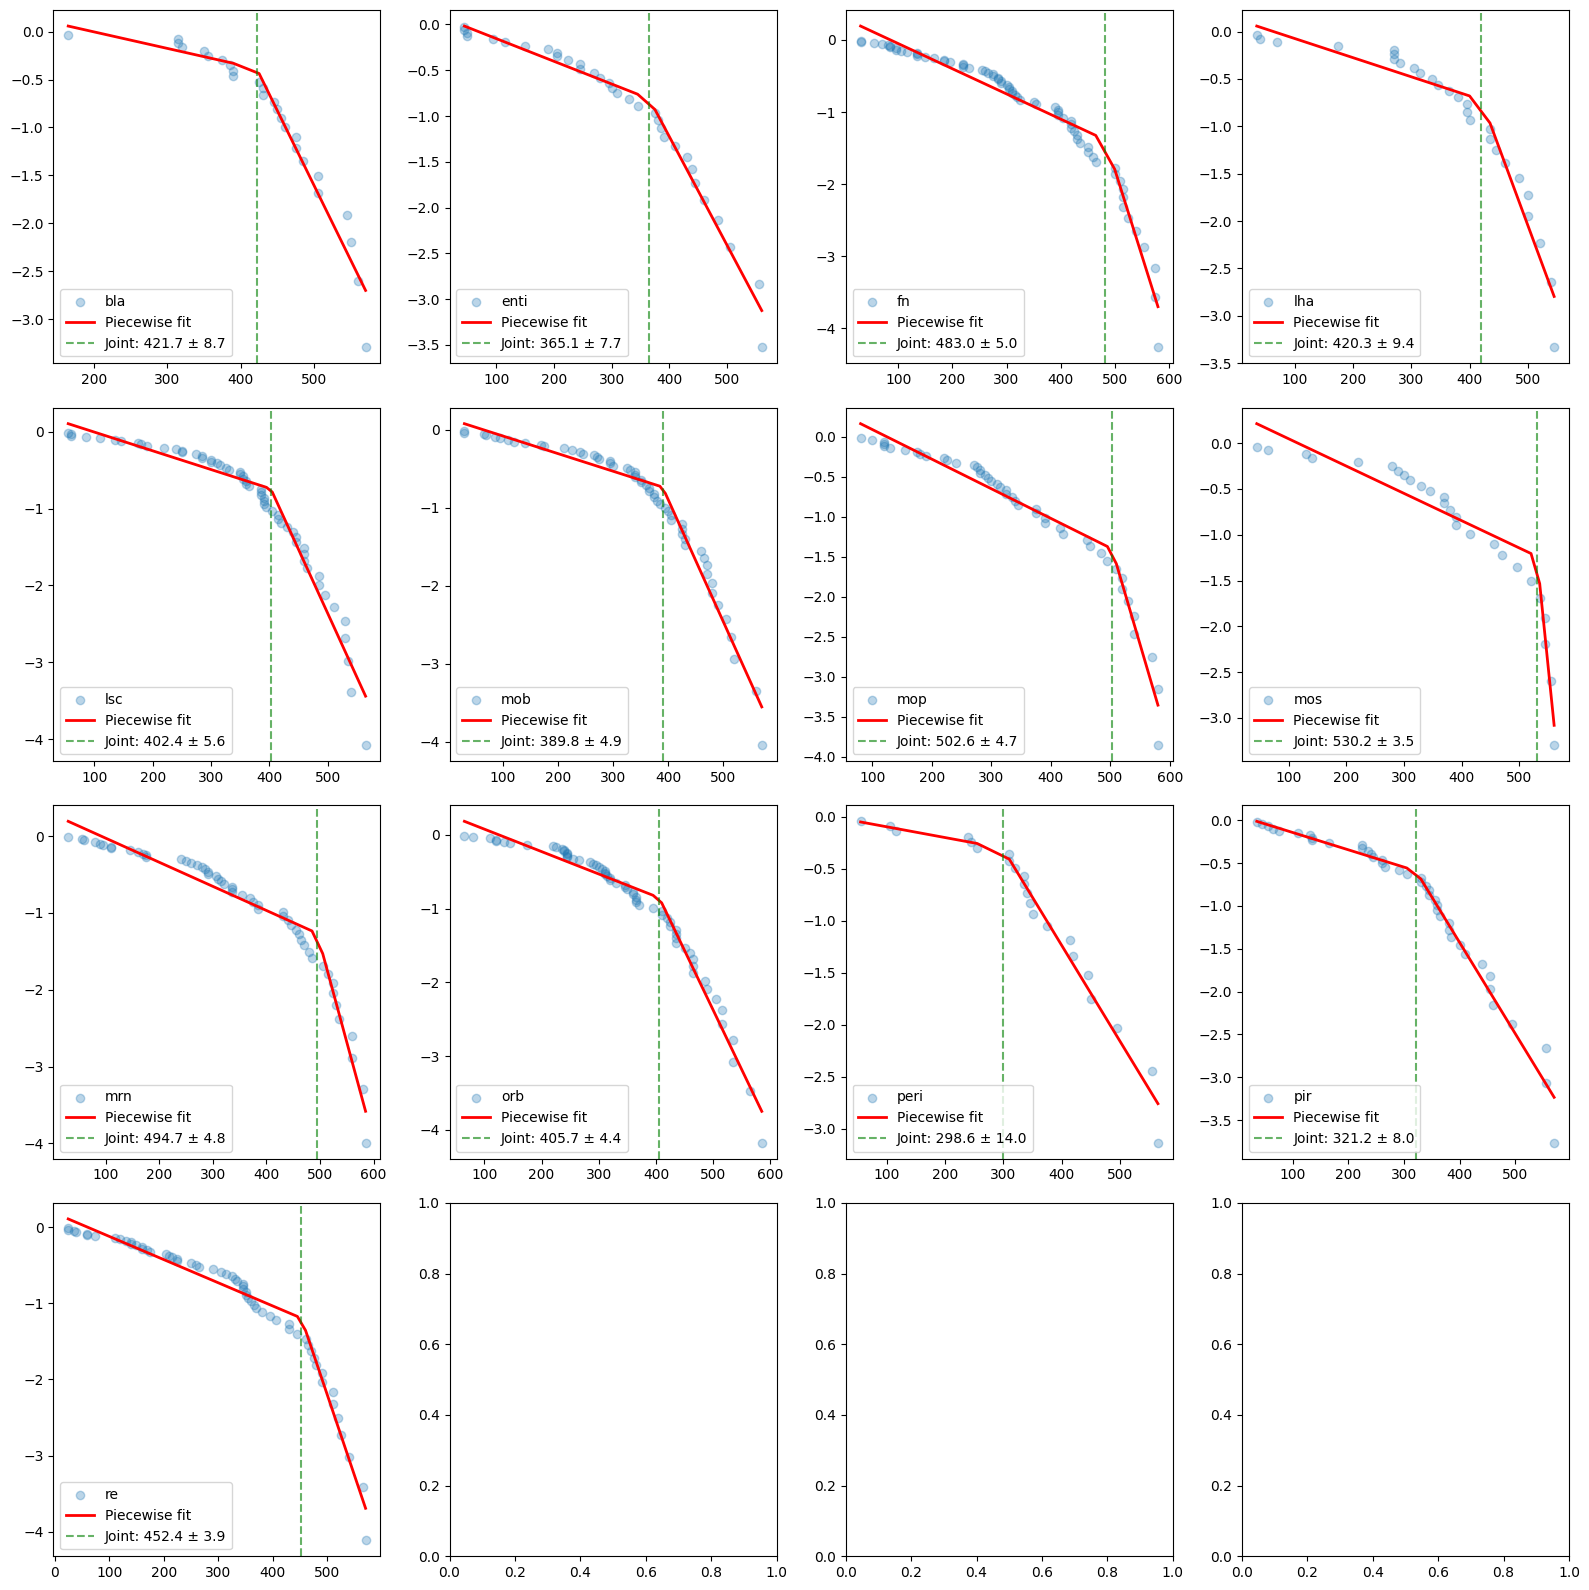

In [35]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()


# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp1_se={}
dict_exp2 = {}
dict_exp2_se={}
dict_joint = {}
dict_joint_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_fpt = [x for x in params[2]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(full_fpt, ax, f"full_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [36]:


# assuming you already have dict_exp1, dict_exp1_se, dict_exp2, dict_exp2_se, dict_joint, dict_joint_se

df_ffpt = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_ffpt)


          exp1   exp1_se      exp2   exp2_se       joint   joint_se
bla  -0.001728  0.000671 -0.015621  0.000799  421.683479   8.659337
enti -0.002481  0.000204 -0.011870  0.000413  365.125723   7.742307
fn   -0.003485  0.000151 -0.023823  0.000951  482.962291   4.964196
lha  -0.002020  0.000343 -0.016637  0.001013  420.288256   9.390053
lsc  -0.002437  0.000232 -0.016600  0.000557  402.362972   5.616855
mob  -0.002259  0.000184 -0.015647  0.000442  389.762357   4.904053
mop  -0.003695  0.000181 -0.025235  0.001226  502.631129   4.708595
mos  -0.002986  0.000286 -0.061895  0.005162  530.181598   3.461103
mrn  -0.003136  0.000162 -0.025649  0.001090  494.713413   4.835315
orb  -0.003042  0.000189 -0.016158  0.000418  405.693517   4.416625
peri -0.001036  0.000427 -0.009226  0.000368  298.578618  14.012461
pir  -0.002017  0.000231 -0.010620  0.000312  321.229955   7.990494
re   -0.003048  0.000133 -0.021232  0.000669  452.405789   3.906501


3. Part ST

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for part_st_bla ---
Joint:   212.0084 ± 3.2484
Slope 1: -0.0186 ± 0.0002
Slope 2: -0.0038 ± 0.0002
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for part_st_enti ---
Joint:   103.7242 ± 1.2625
Slope 1: -0.0287 ± 0.0005
Slope 2: -0.0081 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for part_st_fn ---
Joint:   157.0561 ± 3.9873
Slope 1: -0.0242 ± 0.0003
Slope 2: -0.0137 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for part_st_lha ---
Joint:   125.9049 ± 2.1864
Slope 1: -0.0324 ± 0.0006
Slope 2: -0.0079 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for part_st_lsc ---
Joint:   111.4916 ± 1.8731
Slope 1: -0.0228 ± 0.0004
Slope 2: -0.0079 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--- Res

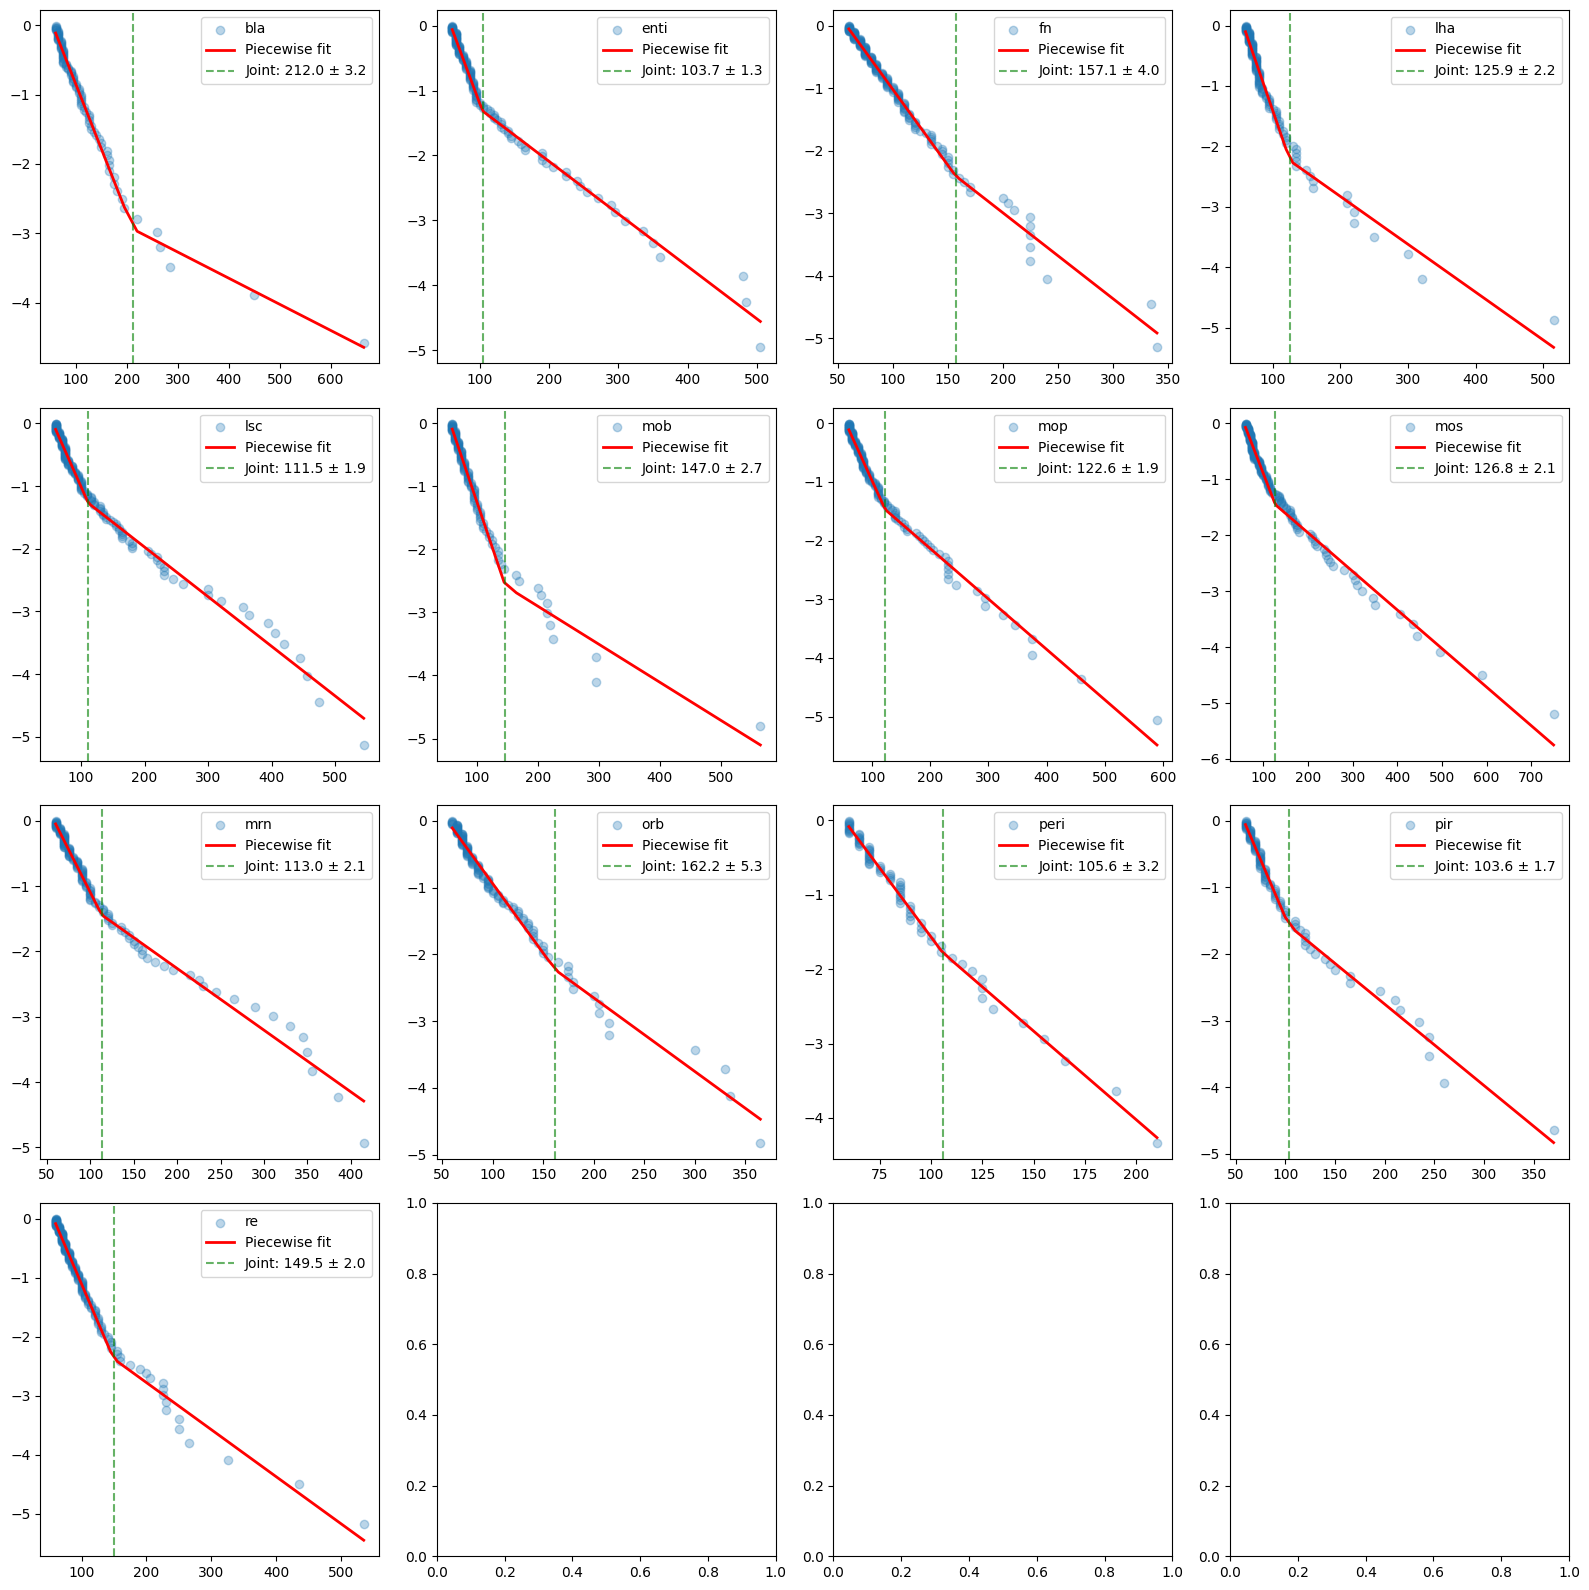

In [37]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp1_se={}
dict_exp2 = {}
dict_exp2_se={}
dict_joint = {}
dict_joint_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_st = [x for x in params[1]["s_t"] if 25 < x < 800]

    p = fit_piecewiseLinear(part_st, ax, f"part_st_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [38]:


# assuming you already have dict_exp1, dict_exp1_se, dict_exp2, dict_exp2_se, dict_joint, dict_joint_se

df_pst = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_pst)


          exp1   exp1_se      exp2   exp2_se       joint  joint_se
bla  -0.018615  0.000184 -0.003764  0.000155  212.008362  3.248383
enti -0.028657  0.000452 -0.008080  0.000099  103.724151  1.262515
fn   -0.024243  0.000252 -0.013739  0.000324  157.056088  3.987275
lha  -0.032448  0.000553 -0.007936  0.000275  125.904920  2.186438
lsc  -0.022843  0.000398 -0.007914  0.000101  111.491639  1.873073
mob  -0.028579  0.000436 -0.006033  0.000267  147.019198  2.668775
mop  -0.021729  0.000291 -0.008587  0.000106  122.592797  1.909576
mos  -0.020674  0.000313 -0.006896  0.000094  126.818594  2.103803
mrn  -0.026260  0.000508 -0.009444  0.000165  112.995749  2.110825
orb  -0.020825  0.000334 -0.011018  0.000361  162.151071  5.281209
peri -0.037069  0.000620 -0.023834  0.000551  105.638539  3.185632
pir  -0.034771  0.000655 -0.012223  0.000248  103.584084  1.703388
re   -0.025589  0.000259 -0.007972  0.000177  149.456279  2.019093


Storing data for figure 6 all lastparams

In [14]:
reader.data_dump_pkl('results/figures/fig6_data.pkl',{'full_fpt':df_ffpt,'part_fpt':df_pfpt,'part_st':df_pst})

4. Full st

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for bla ---
Joint:   271.9118 ± 0.0000
Slope 1: -0.0125 ± 0.0012
Slope 2: -0.0313 ± 0.0110
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for enti ---
Joint:   505.0000 ± 16.8358
Slope 1: -0.0035 ± 0.0002
Slope 2: -0.0098 ± 0.0007
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for fn ---
Joint:   125.1518 ± 0.1423
Slope 1: 0.4641 ± 0.4563
Slope 2: -0.0059 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for lha ---
Joint:   240.5680 ± 12.8278
Slope 1: -0.0187 ± 0.0009
Slope 2: -0.0066 ± 0.0011
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for lsc ---
Joint:   323.1448 ± 3.5873
Slope 1: -0.0068 ± 0.0005
Slope 2: -0.0693 ± 0.0077
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--- Results for mob ---
Joint:   281.2475 ± 10

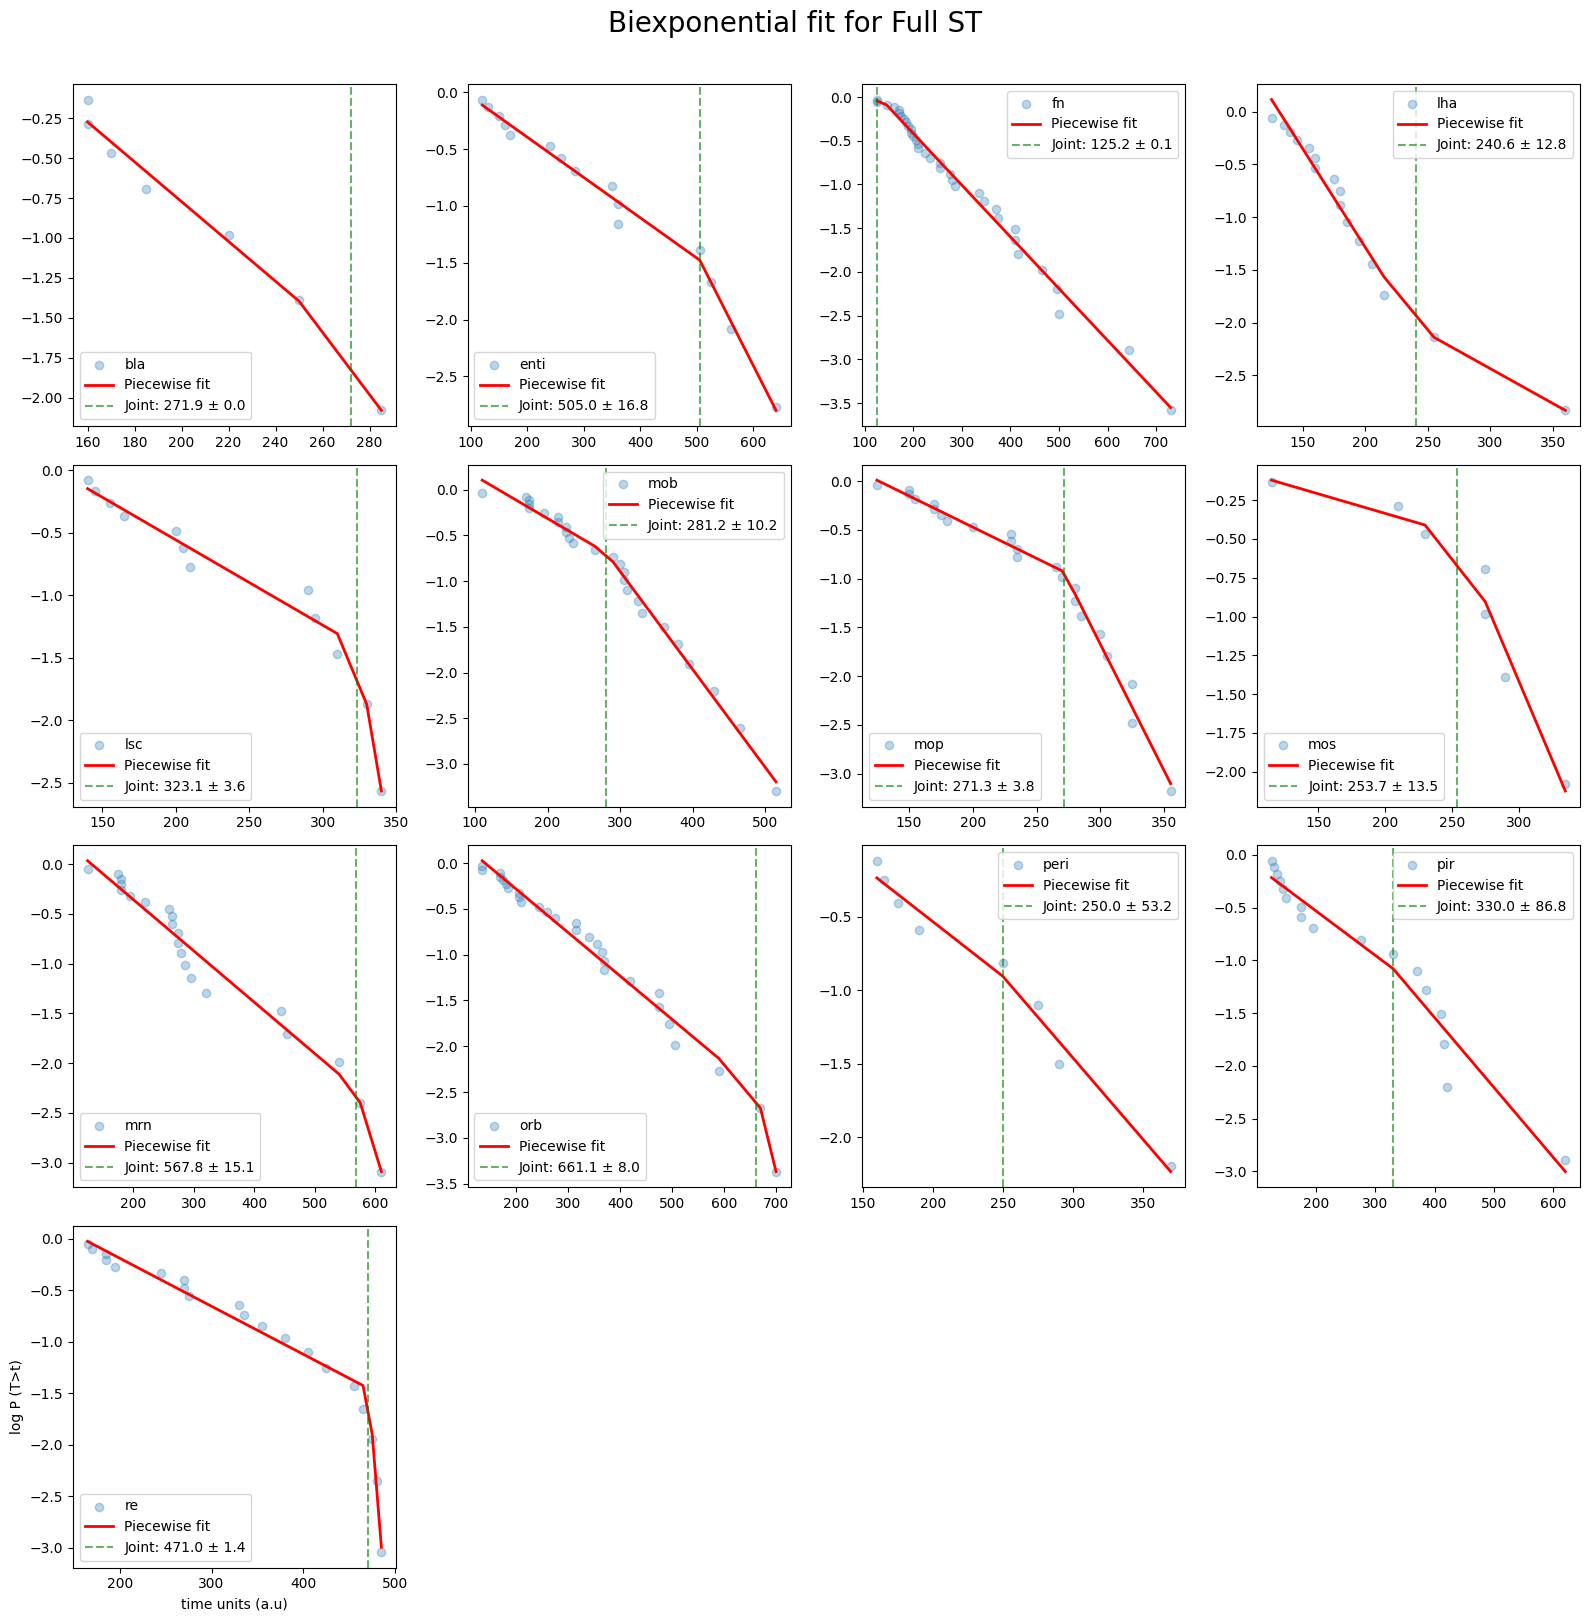

In [39]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))
# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp1_se={}
dict_exp2 = {}
dict_exp2_se={}
dict_joint = {}
dict_joint_se={}
# Flatten axes for easy iteration
axes = axes.flatten()

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_st = [x for x in params[2]["s_t"] if 25 < x < 800]

    

    nw = file.split('_')[-1].split('.')[-2]

    p=fit_piecewiseLinear(full_st, ax, f'{nw}')

    

    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']
    
ax.set_xlabel('time units (a.u)')
ax.set_ylabel('log P (T>t)')
for ax in axes[len(files):]:
    ax.axis("off")

plt.tight_layout()
plt.suptitle('Biexponential fit for Full ST',fontsize=20,y=1.01)
plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [40]:
df_fst = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_fst)

          exp1   exp1_se      exp2   exp2_se       joint   joint_se
bla  -0.012470  0.001194 -0.031313  0.010956  271.911822   0.000020
enti -0.003544  0.000178 -0.009788  0.000717  505.000000  16.835841
fn    0.464116  0.456322 -0.005918  0.000112  125.151795   0.142309
lha  -0.018699  0.000930 -0.006601  0.001099  240.568030  12.827805
lsc  -0.006816  0.000536 -0.069323  0.007705  323.144774   3.587320
mob  -0.004657  0.000372 -0.010709  0.000286  281.247472  10.218407
mop  -0.006417  0.000448 -0.025991  0.001005  271.298809   3.830046
mos  -0.002515  0.001430 -0.020336  0.002487  253.664878  13.498423
mrn  -0.005167  0.000300 -0.019806  0.004335  567.763783  15.075408
orb  -0.004741  0.000142 -0.023106  0.002966  661.149326   8.029712
peri -0.007431  0.001346 -0.011078  0.001356  250.000000  53.186945
pir  -0.004212  0.000671 -0.006624  0.000826  330.000000  86.804406
re   -0.004665  0.000222 -0.109838  0.006776  470.959557   1.373891


In [41]:
data_b=reader.data_read_bz2('results/figures/fig4b_data.pkl')
data_b=data_b

In [42]:
from sklearn.decomposition import PCA
reducer_pca=PCA(n_components=2,random_state=42)
reducer_pca.fit(data_b.values)
clu_tf_pca=reducer_pca.transform(data_b.values)

In [50]:
nw_lbl = [1,2,3,4,5]

Text(0, 0.5, 'PCA 2')

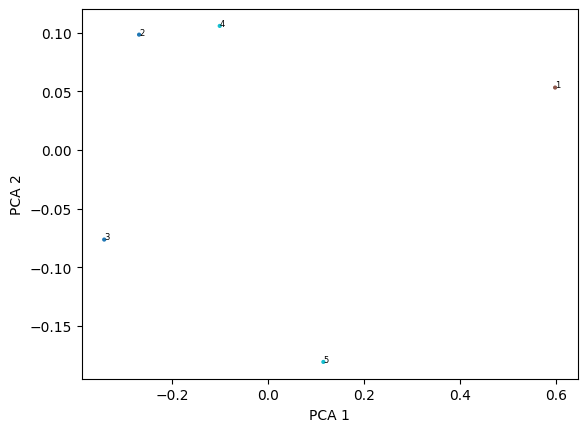

In [54]:
kmeans_pl = KMeans(n_clusters=3, random_state=42)
clus_pl = kmeans_pl.fit_predict(clu_tf_pca)
#scatter plot
plt.scatter(clu_tf_pca[:,0],clu_tf_pca[:,1],c=clus_pl,cmap='tab10',s=4)
for i, label in enumerate(nw_lbl):
    plt.text(clu_tf_pca[i,0], clu_tf_pca[i,1], label, fontsize=6)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

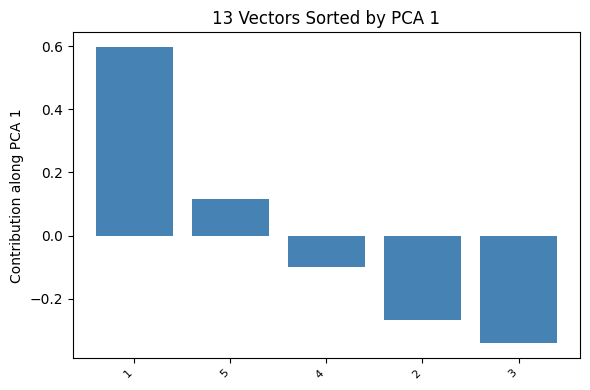

In [52]:
# Extract PCA1 coordinates
pca1_scores = clu_tf_pca[:, 0]

# Sort in descending order
sorted_idx = np.argsort(pca1_scores)[::-1]
sorted_labels = [nw_lbl[i] for i in sorted_idx]
sorted_scores = pca1_scores[sorted_idx]

# Plot
fig, axpca = plt.subplots(figsize=(6,4))
axpca.bar(range(len(sorted_scores)), sorted_scores, color='steelblue')
axpca.set_xticks(range(len(sorted_labels)))
axpca.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=8)
axpca.set_ylabel("Contribution along PCA 1")
axpca.set_title("13 Vectors Sorted by PCA 1")

plt.tight_layout()
plt.show()

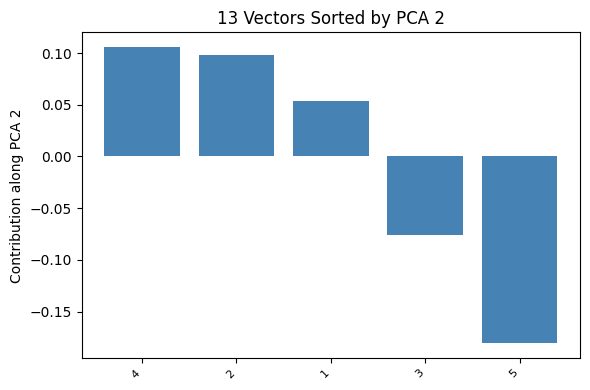

In [53]:
pca1_scores = clu_tf_pca[:, 1]

# Sort in descending order
sorted_idx = np.argsort(pca1_scores)[::-1]
sorted_labels = [nw_lbl[i] for i in sorted_idx]
sorted_scores = pca1_scores[sorted_idx]

# Plot
fig, axpca = plt.subplots(figsize=(6,4))
axpca.bar(range(len(sorted_scores)), sorted_scores, color='steelblue')
axpca.set_xticks(range(len(sorted_labels)))
axpca.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=8)
axpca.set_ylabel("Contribution along PCA 2")
axpca.set_title("13 Vectors Sorted by PCA 2")

plt.tight_layout()
plt.show()

<Axes: >

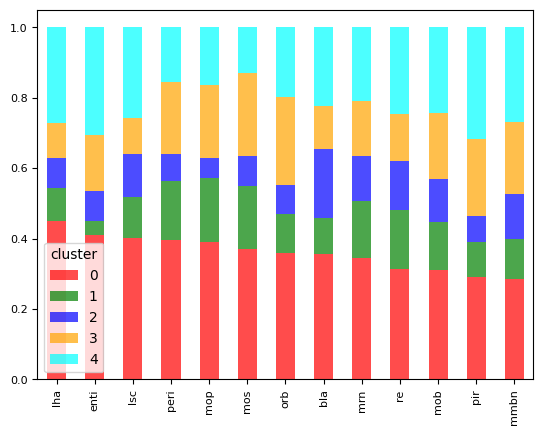

In [21]:
colors=['red','green','blue','orange','cyan']
data_b=data_b.rename(columns={'fn':'mmbn'}).T
data_b=data_b.sort_values(by=0,ascending=False)
data_b.plot(kind='bar',color=colors, stacked=True,alpha=0.7,fontsize=8)

In [22]:
data_b

cluster,0,1,2,3,4
lha,0.450000,0.092857,0.085714,0.100000,0.271429
enti,0.410596,0.039735,0.086093,0.158940,0.304636
lsc,0.401070,0.117647,0.122995,0.101604,0.256684
peri,0.397436,0.166667,0.076923,0.205128,0.153846
mop,0.390244,0.182927,0.054878,0.207317,0.164634
mos,0.370968,0.177419,0.086022,0.236559,0.129032
orb,0.360294,0.110294,0.080882,0.250000,0.198529
bla,0.355140,0.102804,0.196262,0.121495,0.224299
mrn,0.344595,0.162162,0.128378,0.155405,0.209459
re,0.315000,0.165000,0.140000,0.135000,0.245000
